In [1]:
import hvplot.xarray
import numpy as np
import xarray as xr

In [2]:
def load_merged_argo_dataset_and_tumo(time_smoothing, lat_bounds = None, suffix = None):
    ds_argo_merged = xr.open_dataset(f'../rapid-geostrophic-reconstruction/data/ds_argo_{time_smoothing}_viking{suffix}.nc')
    t_umo_obs = xr.open_dataset(f'../rapid-geostrophic-reconstruction/data/t_umo_sim_miss{suffix}.nc')
    t_umo_obs['time'] = t_umo_obs.time.dt.floor('D')
    t_umo_obs = t_umo_obs.resample(time = time_smoothing).mean()

    ds_argo_merged = ds_argo_merged.sel(time = t_umo_obs.time.data)#, method = 'nearest')
    ds_argo_merged = ds_argo_merged.isel(z = slice(None, None, -1))

    if lat_bounds is not None:
        ds_argo_merged = ds_argo_merged.where((ds_argo_merged.lat >= lat_bounds[0]) & (ds_argo_merged.lat <= lat_bounds[1]))

    return ds_argo_merged, t_umo_obs

In [3]:
# Load the argo_dataset and the ground truth dataset

import xarray as xr
import pandas as pd
time_smoothing = '90D'

lat_bounds = (25, 27)


# ds_argo_merged, t_umo_obs = load_merged_argo_dataset_and_tumo(time_smoothing)#, lat_bounds = lat_bounds)

def load_merged_argo_dataset_and_tumo_cycles(suffixe, time_smoothing):
    ds_argo_merged = None
    t_umo_obs = None
    assert len(suffixe) == 2, 'Longer? Think on the t_delta '

    for suffix in suffixe:
        ds_argo_merged_cycle, t_umo_obs_cycle = load_merged_argo_dataset_and_tumo(time_smoothing, suffix= suffix)

        if ds_argo_merged is None:
            ds_argo_merged = ds_argo_merged_cycle
            t_umo_obs = t_umo_obs_cycle
        else:
            t_delta = ds_argo_merged.time.max() - ds_argo_merged_cycle.time.min() + pd.Timedelta(time_smoothing)
            ds_argo_merged_cycle['time'] = ds_argo_merged_cycle['time'] + t_delta 
            t_umo_obs_cycle['time'] = t_umo_obs_cycle['time'] + t_delta
            ds_argo_merged_cycle['time_1d'] = ds_argo_merged_cycle['time_1d'] + t_delta

            ds_argo_merged = xr.concat([ds_argo_merged, ds_argo_merged_cycle], dim = 'time')
            t_umo_obs = xr.concat([t_umo_obs, t_umo_obs_cycle], dim = 'time')

    return ds_argo_merged, t_umo_obs, t_delta

suffixe = ['_70None', '_2nd_NoneNone']
ds_argo_merged, t_umo_obs, t_delta = load_merged_argo_dataset_and_tumo_cycles(suffixe, time_smoothing)

/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


## Single Profile Processing

We will load the ds_argo_merged dataset as thre base where each prfoile in the ten day window is present.
THen we will create 4 embedding one for each of the moorings and each profile is assigned by distance to those emebeddings. 
Each profile will create based on the currtent state and its rho values a delta that will be added to the embedding.

In [4]:
dv_dz_obs_1st = xr.open_dataset('../rapid-geostrophic-reconstruction/data/dv_dz_sim_miss_70None.nc')
dv_dz_obs_1st = dv_dz_obs_1st.resample(time = time_smoothing).mean()
dv_dz_obs_2nd = xr.open_dataset('../rapid-geostrophic-reconstruction/data/dv_dz_sim_miss_2nd_NoneNone.nc')
dv_dz_obs_2nd = dv_dz_obs_2nd.resample(time = time_smoothing).mean()

dv_dz_obs_2nd['time'] = dv_dz_obs_2nd['time'] + t_delta

dv_dz_obs = xr.concat([dv_dz_obs_1st, dv_dz_obs_2nd], dim = 'time')

dv_dz_obs.mean('time').dv_dz_times_X#.interpolate_na('z')

<xarray.DataArray 'dv_dz_times_X' (z: 242)>
array([-4.22443068e+00, -4.21170552e+00, -4.19896027e+00, -4.18619497e+00,
       -4.17340962e+00, -4.16060424e+00, -4.14777885e+00, -4.13493347e+00,
       -4.12206812e+00, -4.10918281e+00, -4.08863467e+00, -4.05972616e+00,
       -4.03097784e+00, -4.00238996e+00, -3.97396276e+00, -3.94569645e+00,
       -3.91759128e+00, -3.88964748e+00, -3.86186528e+00, -3.83424491e+00,
       -3.80678661e+00, -3.77949060e+00, -3.73930077e+00, -3.61436890e+00,
       -3.49033791e+00, -3.36720844e+00, -3.24498112e+00, -3.12365656e+00,
       -3.00323539e+00, -2.88371822e+00, -2.76510566e+00, -2.64739834e+00,
       -2.53059684e+00, -2.41470179e+00, -2.29971377e+00, -2.25224660e+00,
       -2.21665643e+00, -2.18135793e+00, -2.14635105e+00, -2.11163572e+00,
       -2.07721188e+00, -2.04307947e+00, -2.00923842e+00, -1.97568866e+00,
       -1.94243013e+00, -1.90946276e+00, -1.87678648e+00, -1.78949364e+00,
       -1.67303768e+00, -1.55740648e+00, -1.44260020e+00, -1.32861900e+00,
       -1.21546304e+00, -1.10313246e+00, -9.91627425e-01, -8.80948071e-01,
       -7.79175722e-01, -9.55901636e-02, -1.35648852e-01, -2.41910899e-01,
       -4.05047262e-01, -5.67328035e-01, -7.28753479e-01, -8.89323860e-01,
       -1.04903945e+00, -1.20790051e+00, -1.36590733e+00, -1.52306018e+00,
       -1.67935935e+00, -1.83480513e+00, -1.98939781e+00, -2.03174115e+00,
       -1.97846134e+00, -1.92558921e+00, -1.87312412e+00, -1.82106545e+00,
       -1.76941258e+00, -1.71816489e+00, -1.66732174e+00, -1.61688250e+00,
...
        2.69364892e+00,  2.86731437e+00,  3.03974590e+00,  3.21095350e+00,
        4.09594877e+00,  5.58668106e+00,  7.08808531e+00,  8.60017334e+00,
        1.01229572e+01,  1.16564493e+01,  1.32006621e+01,  1.47556084e+01,
        1.63213012e+01,  1.70706913e+01,  1.77152352e+01,  1.83605606e+01,
        1.90066776e+01,  1.96535964e+01,  2.03013270e+01,  2.09498795e+01,
        2.15992641e+01,  2.16362406e+01,  2.15627427e+01,  2.14903288e+01,
        2.14189915e+01,  2.13487235e+01,  2.12795176e+01,  2.12113665e+01,
        2.03527985e+01,  1.85565740e+01,  1.67409281e+01,  1.49058929e+01,
        1.30514997e+01,  1.11777788e+01,  9.28475967e+00,  5.76393674e+00,
        1.59513796e+00, -2.71529678e+00, -7.16627915e+00, -1.17567524e+01,
       -1.64856904e+01, -2.11127913e+01, -2.60489472e+01, -3.14143101e+01,
       -3.72035224e+01, -4.34114273e+01, -4.89884384e+01, -5.34613582e+01,
       -5.84840668e+01, -6.40492091e+01, -7.01497042e+01, -7.67610450e+01,
       -8.38826829e+01, -9.15150604e+01, -9.96520085e+01, -1.05383754e+02,
       -1.09566751e+02, -1.13898145e+02, -1.18085071e+02, -1.19905313e+02,
       -1.21720648e+02, -1.23502545e+02, -1.24997522e+02, -1.26438931e+02,
       -1.29068588e+02, -1.32688494e+02, -1.37705178e+02, -1.44923596e+02,
       -1.54865231e+02, -1.66985482e+02, -1.82266879e+02, -1.99369186e+02,
       -2.17029004e+02, -2.36606839e+02, -2.52466962e+02, -2.68315226e+02,
                   nan,             nan])
Coordinates:
  * z        (z) float64 -4.82e+03 -4.8e+03 -4.78e+03 ... -40.0 -20.0 -0.0

In [5]:
from copy import deepcopy

In [6]:
ds_argo_merged_10days, t_umo_10days, t_delta = load_merged_argo_dataset_and_tumo_cycles(['_70None', '_2nd_NoneNone'], '90D')

compartments = [
    ['west_p', -76.74, -70, 'west'],
    ['mar_west_p', -60, -47, 'east'],
    ['mar_east_p', -47, -40, 'west'],
    ['east_p', -30, -13.5, 'east']
]

# VIKING contains more detailed information in the upper layers as the Argo dataset
# Argo only measures each 20 meters while VIKING has measurments at 0, 3, 9, 12 ... meters

boundaries = np.arange(-10000, 1, 20) + 10
depth_grouped = ds_argo_merged_10days.groupby_bins('z', boundaries).mean()
depth_grouped = depth_grouped.where(ds_argo_merged_10days.z.groupby_bins('z', boundaries).count() > 0)


ds_argo_merged_10days = depth_grouped.assign_coords(z_bins = ('z_bins', np.arange(-10000, 1, 20)[1:])).rename({'z_bins': 'z'}).sel(z = ds_argo_merged_10days.z, method = 'nearest').assign_coords(z = ds_argo_merged_10days.z).transpose('time', 'pos', 'z')

# We only take the first 2000 meters depth
ds_argo_merged_10days = ds_argo_merged_10days.where(ds_argo_merged_10days.z > -2000, drop = True)

ds_argo_merged_10days = ds_argo_merged_10days.where(ds_argo_merged_10days.salinity > 0)
# ds_argo_merged_10days = ds_argo_merged_10days.where((ds_argo_merged_10days.z <= -1500) | (ds_argo_merged_10days.z > -100) , drop = True)
# ds_argo_merged_10days = ds_argo_merged_10days.where((ds_argo_merged_10days.z <= -1500) , drop = True)

ds_argo_merged_10days = ds_argo_merged_10days.sortby('z')

/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


In [7]:
load_std = True

# Prepare a dataset by 1) splitting the data, 2) scaling the input data 
# train_slice_pos = 'start'

# train_ratio = .6
# val_ratio = .15


# t_umo_10days = t_umo_10days.sel(time = slice(None, '2020-01-01'))
# ds_argo_merged_10days = ds_argo_merged_10days.sel(time = slice(None, '2020-01-01'))


# indices = np.arange(t_umo_10days.time.shape[0])
# # np.random.shuffle(indices)


    


# if train_slice_pos == 'start':
#     train_indices = indices[:int(train_ratio * indices.shape[0])]
#     val_indices = indices[int(train_ratio * indices.shape[0]):int((train_ratio + val_ratio) * indices.shape[0])]
#     test_indices = indices[int((train_ratio + val_ratio) * indices.shape[0]):]
# elif train_slice_pos == 'end':
#     train_indices = indices[-int(train_ratio * indices.shape[0]):]
#     val_indices = indices[-int((train_ratio + val_ratio) * indices.shape[0]): -int(train_ratio * indices.shape[0])]
#     test_indices = indices[:-int((train_ratio + val_ratio) * indices.shape[0])]


test_indices = t_umo_10days.assign_coords(ti = ('time', np.arange(len(t_umo_10days.time)))).sel(time = slice('2005-01-01', '2025-01-01')).ti.values

valid_indices_1 =  t_umo_10days.assign_coords(ti = ('time', np.arange(len(t_umo_10days.time)))).sel(time = slice('1990-01-01', '2005-01-01')).ti.values
valid_indices_2 =  t_umo_10days.assign_coords(ti = ('time', np.arange(len(t_umo_10days.time)))).sel(time = slice('2025-01-01','2045-01-01')).ti.values

val_indices = np.concatenate([valid_indices_1, valid_indices_2])

train_mask = ~np.isin(np.arange(t_umo_10days.time.shape[0]), np.concatenate((val_indices, test_indices)))

train_indices = np.arange(t_umo_10days.time.shape[0])[train_mask]


rho_mean = ds_argo_merged_10days.where(ds_argo_merged_10days.profile_mask).mean(['time', 'pos']).rho
temperature_mean = ds_argo_merged_10days.where(ds_argo_merged_10days.profile_mask).mean(['time', 'pos']).temperature
salinity_mean = ds_argo_merged_10days.where(ds_argo_merged_10days.profile_mask).mean(['time', 'pos']).salinity

if load_std:
    temperature_std = xr.open_dataset('../rapid-geostrophic-reconstruction/data/train_temperature_std_argo.nc').temperature
    salinity_std = xr.open_dataset('../rapid-geostrophic-reconstruction/data/train_salinity_std_argo.nc').salinity
    rho_std = xr.open_dataset('../rapid-geostrophic-reconstruction/data/train_rho_std_argo.nc').rho
    std_transport = xr.open_dataset('../rapid-geostrophic-reconstruction/data/train_transport_std_argo.nc').dv_dz_times_X
else:
    rho_std = ds_argo_merged_10days.where(ds_argo_merged_10days.profile_mask).isel(time = train_indices).std(['time', 'pos']).rho
    temperature_std = ds_argo_merged_10days.where(ds_argo_merged_10days.profile_mask).isel(time = train_indices).std(['time', 'pos']).temperature
    salinity_std = ds_argo_merged_10days.where(ds_argo_merged_10days.profile_mask).isel(time = train_indices).std(['time', 'pos']).salinity
    std_transport = t_umo_10days.isel(time = train_indices).std('time').dv_dz_times_X




def standardize_rho(ds_pos, rho_mean=None, rho_std=None):
    ds_pos = deepcopy(ds_pos)
    ds_pos["rho"] = (ds_pos["rho"] - rho_mean) / rho_std
    return ds_pos

def standardize_temperature(ds_pos, temperature_mean=None, temperature_std=None):
    ds_pos = deepcopy(ds_pos)
    ds_pos["temperature"] = (ds_pos["temperature"] - temperature_mean) / temperature_std
    return ds_pos

def standardize_salinity(ds_pos, salinity_mean=None, salinity_std=None):
    ds_pos = deepcopy(ds_pos)
    ds_pos["salinity"] = (ds_pos["salinity"] - salinity_mean) / salinity_std
    return ds_pos


ds_argo_merged_10days_std = standardize_rho(
    ds_argo_merged_10days,
    rho_mean=rho_mean, 
    rho_std=rho_std,
)

ds_argo_merged_10days_std = standardize_temperature(
    ds_argo_merged_10days_std,
    temperature_mean=temperature_mean,
    temperature_std=temperature_std,
)

ds_argo_merged_10days_std = standardize_salinity(
    ds_argo_merged_10days_std,
    salinity_mean=salinity_mean,
    salinity_std=salinity_std,
)

ds_argo_merged_10days_std = ds_argo_merged_10days_std.fillna(0)

nn_feature_ds = xr.concat(
    [
        ds_argo_merged_10days_std.rho, 
        # ds_argo_merged_10days_std.temperature, 
        # ds_argo_merged_10days_std.salinity
        ], dim = 'feature'
).stack(nn_feature = ['feature', 'z'])
train_X_scaled = nn_feature_ds.isel(time = train_indices).values
val_X_scaled = nn_feature_ds.isel(time = val_indices).values
test_X_scaled = nn_feature_ds.isel(time = test_indices).values


train_X_mask = ds_argo_merged_10days.isel(time = train_indices).profile_mask.fillna(0).astype(bool).values
val_X_mask = ds_argo_merged_10days.isel(time = val_indices).profile_mask.fillna(0).astype(bool).values
test_X_mask = ds_argo_merged_10days.isel(time = test_indices).profile_mask.fillna(0).astype(bool).values

train_X_lon = ds_argo_merged_10days.isel(time = train_indices).lon.values
val_X_lon = ds_argo_merged_10days.isel(time = val_indices).lon.values
test_X_lon = ds_argo_merged_10days.isel(time = test_indices).lon.values

offset_days = (
    (
        ds_argo_merged_10days.time_1d -
        ds_argo_merged_10days.time
    )
    .fillna(0).dt.days 
)

train_X_days = offset_days.isel(time = train_indices).values
val_X_days = offset_days.isel(time = val_indices).values
test_X_days = offset_days.isel(time = test_indices).values

train_y = t_umo_10days.isel(time = train_indices).dv_dz_times_X
val_y = t_umo_10days.isel(time = val_indices).dv_dz_times_X
test_y = t_umo_10days.isel(time = test_indices).dv_dz_times_X

mean_transport  = train_y.mean('time')

train_y_scaled = (train_y - mean_transport) / std_transport
val_y_scaled = (val_y - mean_transport) / std_transport
test_y_scaled = (test_y - mean_transport) / std_transport

train_y_scaled = train_y_scaled.fillna(0).values
val_y_scaled = val_y_scaled.fillna(0).values
test_y_scaled = test_y_scaled.fillna(0).values

# dv_dz_obs = xr.open_dataset('../rapid-geostrophic-reconstruction/data/dv_dz_sim_miss_70None.nc')
# dv_dz_obs = dv_dz_obs.resample(time = time_smoothing).mean()
dv_dz_moorings = dv_dz_obs.sel(time = ds_argo_merged_10days.time).where(dv_dz_obs.z <= -2000, drop = True)

mean_dv_dz_moorings = dv_dz_moorings.isel(time = train_indices).mean(['time']).dv_dz_times_X
std_dv_dz_moorings = dv_dz_moorings.isel(time = train_indices).std(['time']).dv_dz_times_X

train_dv_dz_moorings_scaled = ((dv_dz_moorings.isel(time = train_indices).dv_dz_times_X - mean_dv_dz_moorings) / std_dv_dz_moorings).fillna(0).values
val_dv_dz_moorings_scaled = ((dv_dz_moorings.isel(time = val_indices).dv_dz_times_X - mean_dv_dz_moorings) / std_dv_dz_moorings).fillna(0).values
test_dv_dz_moorings_scaled = ((dv_dz_moorings.isel(time = test_indices).dv_dz_times_X - mean_dv_dz_moorings) / std_dv_dz_moorings).fillna(0).values



ds_argo_merged_10days


<xarray.Dataset>
Dimensions:       (time: 485, pos: 671, z: 29)
Coordinates:
  * time          (time) datetime64[ns] 1970-04-01 1970-06-30 ... 2089-07-05
  * pos           (pos) int64 0 1 2 3 4 5 6 7 ... 664 665 666 667 668 669 670
  * z             (z) float32 -1.85e+03 -1.655e+03 -1.471e+03 ... -9.454 -3.047
    lon           (time, pos) float32 -34.6 -68.3 -62.8 -16.55 ... nan nan nan
    lat           (time, pos) float32 25.88 27.11 28.08 28.72 ... nan nan nan
    time_1d       (time, pos) datetime64[ns] 1970-02-16T12:00:00 ... NaT
    pressure      (z) float32 1.85e+03 1.655e+03 1.471e+03 ... 16.36 9.454 3.047
Data variables:
    temperature   (time, pos, z) float32 nan nan nan nan nan ... nan nan nan nan
    salinity      (time, pos, z) float32 nan nan nan nan nan ... nan nan nan nan
    profile_mask  (time, pos, z) float64 nan nan nan nan nan ... nan nan nan nan
    ct            (time, pos, z) float64 nan nan nan nan nan ... nan nan nan nan
    rho           (time, pos, z) float64 nan nan nan nan nan ... nan nan nan nan

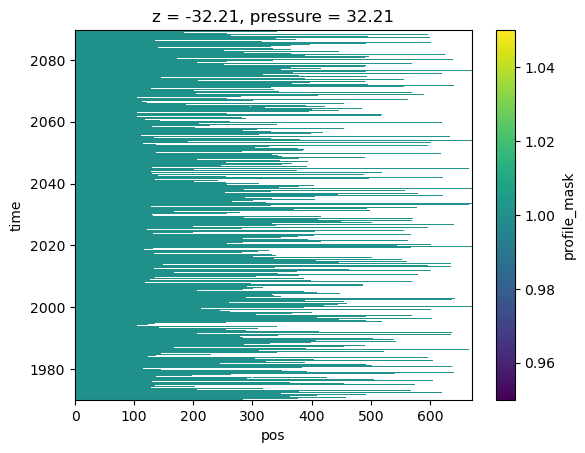

In [8]:
ds_argo_merged_10days.profile_mask.isel(z = -5).plot()

In [9]:
ds_argo_merged_10days.where((ds_argo_merged_10days.profile_mask)).isel(time = train_indices).rho.isel(z = -2).hvplot.kde()

:NdOverlay   [Variable]
   :Distribution   [value]   (Density)

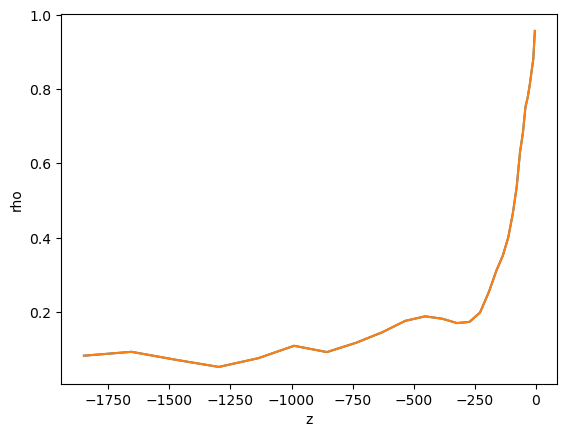

In [10]:
xr.open_dataset('../rapid-geostrophic-reconstruction/data/train_rho_std_argo.nc').rho.plot()
rho_std.plot()

In [11]:
from torch.utils.data import DataLoader, TensorDataset, Dataset
class ProfileDataset(Dataset):
    def __init__(self, X, y, mask, lon, dv_dz, days, compartments):
        self.X = X
        self.y = y
        self.mask = mask
        self.lon = lon
        self.days = days
        self.compartment = compartments 
        self.dv_dz = dv_dz

        self.len_compartments = len(compartments)

        self.X_per_compartment = []
        self.lon_per_compartment = []
        self.dv_dz_per_compartment = []
        self.days_per_compartment = []

        self.min_longitude = min([comp[1] for comp in compartments])
        self.max_longitude = max([comp[2] for comp in compartments])



        self.lon_scaled = (self.lon - self.min_longitude) / (self.max_longitude - self.min_longitude)

        self.days_scaled = self.days / (pd.Timedelta(time_smoothing).days / 2)
        
        for i in range(len(self)):
            mask = self.mask[i]


            compartment_X_per_sample = []
            compartment_lon_per_sample = []
            compartment_days_per_sample = []

            for j in range(self.len_compartments):

                # get all profile indices that are in the compartment and in the mask 
                profile_indices = np.where((self.lon[i] > self.compartment[j][1]) & (self.lon[i] < self.compartment[j][2]) & mask.any(axis = -1))[0]

                if len(profile_indices) < 1:
                    compartment_X_per_sample.append(np.empty(0))
                    compartment_lon_per_sample.append(np.empty(0))
                    compartment_days_per_sample.append(np.empty(0))
                    continue

                lon_compartments = self.lon_scaled[i][profile_indices]
                sorted_indices_longitude = lon_compartments.argsort()


                # If I have the sequence -5, -15, 5 the argsort will return [1, 0, 2]
                # As we want to have those profiles as last that are closes to the mooring due to the vanishing gradient 
                # For West moorings the smallest value has to be the last one
                if self.compartment[j][3] == 'west':
                    sorted_indices_longitude = sorted_indices_longitude[::-1]
                
                profile_indices = profile_indices[sorted_indices_longitude]

                compartment_X_per_sample.append(self.X[i][ profile_indices])
                compartment_lon_per_sample.append(self.lon_scaled[i][profile_indices])
                compartment_days_per_sample.append(self.days_scaled[i][profile_indices])
            

            self.X_per_compartment.append(compartment_X_per_sample)
            self.lon_per_compartment.append(compartment_lon_per_sample)
            self.dv_dz_per_compartment.append(self.dv_dz[i])
            self.days_per_compartment.append(compartment_days_per_sample)


    def __len__(self):
        return self.X.shape[0] 

    def __getitem__(self, idx):
        return self.X_per_compartment[idx], self.y[idx], self.lon_per_compartment[idx], self.dv_dz_per_compartment[idx], self.days_per_compartment[idx]

In [12]:
import torch
train_dataset = ProfileDataset(train_X_scaled, train_y, train_X_mask, train_X_lon, train_dv_dz_moorings_scaled, train_X_days, compartments)
val_dataset = ProfileDataset(val_X_scaled, val_y, val_X_mask, val_X_lon, val_dv_dz_moorings_scaled, val_X_days, compartments)
test_dataset = ProfileDataset(test_X_scaled, test_y, test_X_mask, test_X_lon, test_dv_dz_moorings_scaled, test_X_days, compartments)
    
device = 'cuda' if torch.cuda.is_available() else 'cpu'

def merge_profiles(data):
    """
        X: is a list and each entry is a list of compartments in which the profiles are stored with variable length
    """
    X, y, lon, dv_dz, days = zip(*data)
    X = [[torch.tensor(x_compartment).float().to(device) for x_compartment in x_sample] for x_sample in X]
    y = torch.tensor(np.array(y)).float().to(device)
    lon = [[torch.tensor(lon_compartment).float().to(device) for lon_compartment in lon_sample] for lon_sample in lon]
    dv_dz = [torch.tensor(dv_dz_sample).float().to(device) for dv_dz_sample in dv_dz]
    days = [[torch.tensor(days_compartment).float().to(device) for days_compartment in day_sample] for day_sample in days]

    

    return X, y, lon, dv_dz, days

dl = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=merge_profiles)
val_dl = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=merge_profiles)
test_dl = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=merge_profiles)


In [13]:
ds_argo_merged_10days

<xarray.Dataset>
Dimensions:       (time: 485, pos: 671, z: 29)
Coordinates:
  * time          (time) datetime64[ns] 1970-04-01 1970-06-30 ... 2089-07-05
  * pos           (pos) int64 0 1 2 3 4 5 6 7 ... 664 665 666 667 668 669 670
  * z             (z) float32 -1.85e+03 -1.655e+03 -1.471e+03 ... -9.454 -3.047
    lon           (time, pos) float32 -34.6 -68.3 -62.8 -16.55 ... nan nan nan
    lat           (time, pos) float32 25.88 27.11 28.08 28.72 ... nan nan nan
    time_1d       (time, pos) datetime64[ns] 1970-02-16T12:00:00 ... NaT
    pressure      (z) float32 1.85e+03 1.655e+03 1.471e+03 ... 16.36 9.454 3.047
Data variables:
    temperature   (time, pos, z) float32 nan nan nan nan nan ... nan nan nan nan
    salinity      (time, pos, z) float32 nan nan nan nan nan ... nan nan nan nan
    profile_mask  (time, pos, z) float64 nan nan nan nan nan ... nan nan nan nan
    ct            (time, pos, z) float64 nan nan nan nan nan ... nan nan nan nan
    rho           (time, pos, z) float64 nan nan nan nan nan ... nan nan nan nan

## Models

### SUSTeR LIB

In [84]:
#Original SUSTeR
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.init as init
import math

class Align(nn.Module):
    def __init__(self, c_in, c_out):
        super(Align, self).__init__()
        self.c_in = c_in
        self.c_out = c_out
        self.align_conv = nn.Conv2d(
            in_channels=c_in, out_channels=c_out, kernel_size=(1, 1))

    def forward(self, x):
        if self.c_in > self.c_out:
            x = self.align_conv(x)
        elif self.c_in < self.c_out:
            batch_size, _, timestep, n_vertex = x.shape
            x = torch.cat([x, torch.zeros(
                [batch_size, self.c_out - self.c_in, timestep, n_vertex]).to(x)], dim=1)
        else:
            x = x

        return x


class CausalConv1d(nn.Conv1d):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, enable_padding=False, dilation=1, groups=1, bias=True):
        if enable_padding == True:
            self.__padding = (kernel_size - 1) * dilation
        else:
            self.__padding = 0
        super(CausalConv1d, self).__init__(in_channels, out_channels, kernel_size=kernel_size,
                                           stride=stride, padding=self.__padding, dilation=dilation, groups=groups, bias=bias)

    def forward(self, input):
        result = super(CausalConv1d, self).forward(input)
        if self.__padding != 0:
            return result[:, :, : -self.__padding]

        return result


class CausalConv2d(nn.Conv2d):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, enable_padding=False, dilation=1, groups=1, bias=True):
        kernel_size = nn.modules.utils._pair(kernel_size)
        stride = nn.modules.utils._pair(stride)
        dilation = nn.modules.utils._pair(dilation)
        if enable_padding == True:
            self.__padding = [int((kernel_size[i] - 1) * dilation[i])
                              for i in range(len(kernel_size))]
        else:
            self.__padding = 0
        self.left_padding = nn.modules.utils._pair(self.__padding)
        super(CausalConv2d, self).__init__(in_channels, out_channels, kernel_size,
                                           stride=stride, padding=0, dilation=dilation, groups=groups, bias=bias)

    def forward(self, input):
        if self.__padding != 0:
            input = F.pad(
                input, (self.left_padding[1], 0, self.left_padding[0], 0))
        result = super(CausalConv2d, self).forward(input)

        return result


class TemporalConvLayer(nn.Module):

    # Temporal Convolution Layer (GLU)
    #
    #        |--------------------------------| * Residual Connection *
    #        |                                |
    #        |    |--->--- CasualConv2d ----- + -------|
    # -------|----|                                   ⊙ ------>
    #             |--->--- CasualConv2d --- Sigmoid ---|
    #

    # param x: tensor, [bs, c_in, ts, n_vertex]

    def __init__(self, Kt, c_in, c_out, n_vertex, act_func):
        super(TemporalConvLayer, self).__init__()
        self.Kt = Kt
        self.c_in = c_in
        self.c_out = c_out
        self.n_vertex = n_vertex
        self.align = Align(c_in, c_out)
        if act_func == 'glu' or act_func == 'gtu':
            self.causal_conv = CausalConv2d(
                in_channels=c_in, out_channels=2 * c_out, kernel_size=(Kt, 1), enable_padding=False, dilation=1)
        else:
            self.causal_conv = CausalConv2d(in_channels=c_in, out_channels=c_out, kernel_size=(
                Kt, 1), enable_padding=False, dilation=1)
        self.act_func = act_func
        self.sigmoid = nn.Sigmoid()
        self.tanh = nn.Tanh()
        self.relu = nn.ReLU()
        self.leaky_relu = nn.LeakyReLU()
        self.silu = nn.SiLU()

    def forward(self, x):
        x_in = self.align(x)[:, :, self.Kt - 1:, :]
        x_causal_conv = self.causal_conv(x)

        if self.act_func == 'glu' or self.act_func == 'gtu':
            x_p = x_causal_conv[:, : self.c_out, :, :]
            x_q = x_causal_conv[:, -self.c_out:, :, :]

            if self.act_func == 'glu':
                # GLU was first purposed in
                # *Language Modeling with Gated Convolutional Networks*.
                # URL: https://arxiv.org/abs/1612.08083
                # Input tensor X is split by a certain dimension into tensor X_a and X_b.
                # In the original paper, GLU is defined as Linear(X_a) ⊙ Sigmoid(Linear(X_b)).
                # However, in PyTorch, GLU is defined as X_a ⊙ Sigmoid(X_b).
                # URL: https://pytorch.org/docs/master/nn.functional.html#torch.nn.functional.glu
                # Because in original paper, the representation of GLU and GTU is ambiguous.
                # So, it is arguable which one version is correct.

                # (x_p + x_in) ⊙ Sigmoid(x_q)
                x = torch.mul((x_p + x_in), self.sigmoid(x_q))

            else:
                # Tanh(x_p + x_in) ⊙ Sigmoid(x_q)
                x = torch.mul(self.tanh(x_p + x_in), self.sigmoid(x_q))

        elif self.act_func == 'relu':
            x = self.relu(x_causal_conv + x_in)

        elif self.act_func == 'leaky_relu':
            x = self.leaky_relu(x_causal_conv + x_in)

        elif self.act_func == 'silu':
            x = self.silu(x_causal_conv + x_in)

        else:
            raise NotImplementedError(
                f'ERROR: The activation function {self.act_func} is not implemented.')

        return x


class ChebGraphConv(nn.Module):
    def __init__(self, c_in, c_out, Ks, bias):
        super(ChebGraphConv, self).__init__()
        self.c_in = c_in
        self.c_out = c_out
        self.Ks = Ks
        self.weight = nn.Parameter(torch.FloatTensor(Ks, c_in, c_out))
        if bias:
            self.bias = nn.Parameter(torch.FloatTensor(c_out))
        else:
            self.register_parameter('bias', None)
        self.reset_parameters()

    def reset_parameters(self):
        init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        if self.bias is not None:
            fan_in, _ = init._calculate_fan_in_and_fan_out(self.weight)
            bound = 1 / math.sqrt(fan_in) if fan_in > 0 else 0
            init.uniform_(self.bias, -bound, bound)

    def forward(self, x, gso):
        #bs, c_in, ts, n_vertex = x.shape
        x = torch.permute(x, (0, 2, 3, 1))

        gso = gso.to(x.device)

        if self.Ks - 1 < 0:
            raise ValueError(
                f'ERROR: the graph convolution kernel size Ks has to be a positive integer, but received {self.Ks}.')
        elif self.Ks - 1 == 0:
            x_0 = x
            x_list = [x_0]
        elif self.Ks - 1 == 1:
            x_0 = x
            x_1 = torch.einsum('bhi,btij->bthj', gso, x)
            x_list = [x_0, x_1]
        elif self.Ks - 1 >= 2:
            x_0 = x
            x_1 = torch.einsum('bhi,btij->bthj', gso, x)
            x_list = [x_0, x_1]
            for k in range(2, self.Ks):
                x_list.append(torch.einsum('bhi,btij->bthj', 2 *
                              gso, x_list[k - 1]) - x_list[k - 2])

        x = torch.stack(x_list, dim=2)

        cheb_graph_conv = torch.einsum('btkhi,kij->bthj', x, self.weight)

        if self.bias is not None:
            cheb_graph_conv = torch.add(cheb_graph_conv, self.bias)
        else:
            cheb_graph_conv = cheb_graph_conv

        return cheb_graph_conv


class GraphConv(nn.Module):
    def __init__(self, c_in, c_out, bias):
        super(GraphConv, self).__init__()
        self.c_in = c_in
        self.c_out = c_out
        self.weight = nn.Parameter(torch.FloatTensor(c_in, c_out))
        if bias:
            self.bias = nn.Parameter(torch.FloatTensor(c_out))
        else:
            self.register_parameter('bias', None)
        self.reset_parameters()

    def reset_parameters(self):
        init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        if self.bias is not None:
            fan_in, _ = init._calculate_fan_in_and_fan_out(self.weight)
            bound = 1 / math.sqrt(fan_in) if fan_in > 0 else 0
            init.uniform_(self.bias, -bound, bound)

    def forward(self, x, gso):
        #bs, c_in, ts, n_vertex = x.shape
        x = torch.permute(x, (0, 2, 3, 1))

        first_mul = torch.einsum('hi,btij->bthj', gso, x)
        second_mul = torch.einsum('bthi,ij->bthj', first_mul, self.weight)

        if self.bias is not None:
            graph_conv = torch.add(second_mul, self.bias)
        else:
            graph_conv = second_mul

        return graph_conv


class GraphConvLayer(nn.Module):
    def __init__(self, graph_conv_type, c_in, c_out, Ks, bias):
        super(GraphConvLayer, self).__init__()
        self.graph_conv_type = graph_conv_type
        self.c_in = c_in
        self.c_out = c_out
        self.align = Align(c_in, c_out)
        self.Ks = Ks
        if self.graph_conv_type == 'cheb_graph_conv':
            self.cheb_graph_conv = ChebGraphConv(c_out, c_out, Ks, bias)
        elif self.graph_conv_type == 'graph_conv':
            self.graph_conv = GraphConv(c_out, c_out, bias)

    def forward(self, x, gso):
        x_gc_in = self.align(x)
        if self.graph_conv_type == 'cheb_graph_conv':
            x_gc = self.cheb_graph_conv(x_gc_in, gso)
        elif self.graph_conv_type == 'graph_conv':
            x_gc = self.graph_conv(x_gc_in, gso)
        x_gc = x_gc.permute(0, 3, 1, 2)
        x_gc_out = torch.add(x_gc, x_gc_in)

        return x_gc_out


class STConvBlock(nn.Module):
    # STConv Block contains 'TGTND' structure
    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # G: Graph Convolution Layer (ChebGraphConv or GraphConv)
    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # N: Layer Normolization
    # D: Dropout

    def __init__(self, Kt, Ks, n_vertex, last_block_channel, channels, act_func, graph_conv_type, bias, droprate):
        super(STConvBlock, self).__init__()
        self.tmp_conv1 = TemporalConvLayer(
            Kt, last_block_channel, channels[0], n_vertex, act_func)
        self.graph_conv = GraphConvLayer(
            graph_conv_type, channels[0], channels[1], Ks, bias)
        self.tmp_conv2 = TemporalConvLayer(
            Kt, channels[1], channels[2], n_vertex, act_func)
        self.tc2_ln = nn.LayerNorm([n_vertex, channels[2]])
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=droprate)

    def forward(self, x, gso):
        x = self.tmp_conv1(x)
        x = self.graph_conv(x, gso)
        x = self.relu(x)
        x = self.tmp_conv2(x)
        x = self.tc2_ln(x.permute(0, 2, 3, 1)).permute(0, 3, 1, 2)
        x = self.dropout(x)

        return x, gso


class OutputBlock(nn.Module):
    # Output block contains 'TNFF' structure
    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # N: Layer Normolization
    # F: Fully-Connected Layer
    # F: Fully-Connected Layer

    def __init__(self, Ko, last_block_channel, channels, end_channel, n_vertex, act_func, bias, droprate):
        super(OutputBlock, self).__init__()
        self.tmp_conv1 = TemporalConvLayer(
            Ko, last_block_channel, channels[0], n_vertex, act_func)
        self.fc1 = nn.Linear(
            in_features=channels[0], out_features=channels[1], bias=bias)
        self.fc2 = nn.Linear(
            in_features=channels[1], out_features=end_channel, bias=bias)
        self.tc1_ln = nn.LayerNorm([n_vertex, channels[0]])
        self.relu = nn.ReLU()
        self.leaky_relu = nn.LeakyReLU()
        self.silu = nn.SiLU()
        self.dropout = nn.Dropout(p=droprate)

    def forward(self, x):
        x = self.tmp_conv1(x)
        x = self.tc1_ln(x.permute(0, 2, 3, 1))
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x).permute(0, 3, 1, 2)

        return x


class ContextAwareMeanState(nn.Module):

    def __init__(self, n_proxy, n_embedding, n_context) -> None:
        super().__init__()

        self.n_proxy = n_proxy
        self.n_embedding = n_embedding

        self.fc1 = nn.Linear(n_context, n_embedding)
        self.fc2 = nn.Linear(n_embedding, n_proxy * n_embedding)


    def forward(self, context):

        global_embed = self.fc1(context)
        global_embed = F.relu(global_embed)

        Xbar = self.fc2(global_embed)

        return Xbar.reshape(-1, self.n_proxy, self.n_embedding)
    

class Embedding(nn.Module):

    def __init__(self, embed_dim, obs_dim, n_proxy) -> None:
        super().__init__()
        self.fc1_1 = nn.Linear(obs_dim + embed_dim * n_proxy, embed_dim)
        self.fc1_2 = nn.Linear(embed_dim , embed_dim)

        self.fc2_1 = nn.Linear(2, n_proxy)
        self.fc2_2 = nn.Linear(n_proxy, n_proxy)

        self.fc3_1 = nn.Linear(embed_dim, embed_dim)

        self.embed_dim = embed_dim
        self.n_proxy = n_proxy

    def forward(self, obs, v):
        
        ## Concat O and X for the embedding vector. 
        input = torch.concat((obs, v.reshape( -1).unsqueeze(dim = 0).expand(obs.shape[0], -1)), dim = -1)
        
        ## Create from the O and X the piece of information that should be incorporated into the network.
        x_emebdding = self.fc1_1(input)
        x_emebdding = F.relu(x_emebdding)
        x_emebdding = self.fc1_2(x_emebdding)
        x_emebdding = F.relu(x_emebdding)


        ## Use the position of the observations to find the best matching hidden node.
        positions = obs[..., :2]
        x_proxies = self.fc2_1(positions)
        x_proxies = F.relu(x_proxies)
        x_proxies = self.fc2_2(x_proxies)

        proxy_density = F.softmax(x_proxies, dim = -1) 

        ## Sample a single graph node from the created distributions and add the information to those nodes.
        sampled_proxy_index = torch.multinomial(proxy_density.reshape(-1, self.n_proxy), 1)
        mask = F.one_hot(sampled_proxy_index, num_classes = self.n_proxy).float().reshape(proxy_density.shape)
       
        obs_mask = torch.any(obs != 0, dim = -1).unsqueeze(dim=-1).expand(-1, self.n_proxy)
        mask = torch.mul(obs_mask, mask)

        new_information = self.fc3_1(x_emebdding)
        dotV_obs = torch.matmul(mask.unsqueeze(dim = -1), new_information.unsqueeze(dim = -2))

        return dotV_obs, mask

class SimpleOutput(nn.Module):

    def __init__(self, n_proxy, embed_dim, n_target) -> None:
        super().__init__()

        self.fc1 = nn.Linear(n_proxy * embed_dim, 256)
        self.fc2 = nn.Linear(256, 128)

        self.map = nn.Linear(128, n_target)

    def forward(self, VF, TP):

        x = self.fc1(VF)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.relu(x)
        y = self.map(x)

        return y

class LocationBasedOutputv2(nn.Module):

    def __init__(self, n_proxy, embed_dim, targets) -> None:
        super().__init__()

        self.reduce = nn.Sequential(
            nn.Linear(n_proxy * embed_dim, 256),
            nn.ReLU(),
            nn.Linear(256,embed_dim)
        )

        self.proxy_porportion = nn.Sequential(
            nn.Linear(4 + embed_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, n_proxy)
        )
        self.fc3 = nn.Linear(embed_dim, embed_dim)
        self.map = nn.Linear(embed_dim, 1)

        self.n_proxy = n_proxy
        self.embed_dim = embed_dim


    def forward(self, VF, target_positions):

        global_state = self.reduce(VF).unsqueeze(dim = 1)
        pos_with_glob_state = torch.concat((global_state.expand(-1, target_positions.shape[0], -1), target_positions.unsqueeze(dim = 0).expand(VF.shape[0], -1, -1)), dim=-1)
        p_proxy = F.softmax(F.relu(self.proxy_porportion(pos_with_glob_state)), dim = -1)


        VF = VF.reshape(VF.shape[0], self.n_proxy, self.embed_dim)
        accumulated_information = torch.einsum('bsp,bpe->bse', p_proxy, VF)

        x = self.fc3(accumulated_information)
        x = F.relu(x)
        y = self.map(x) 

        return y

class mySequential(nn.Sequential):
    def forward(self, *input):
        for module in self._modules.values():
            input = module(*input)
        return input


class STGCNChebGraphConv(nn.Module):
    """
    Paper: Spatio-Temporal Graph Convolutional Networks: A Deep Learning Framework for Trafﬁc Forecasting
    Official Code: https://github.com/VeritasYin/STGCN_IJCAI-18 (tensorflow)
    Ref Code: https://github.com/hazdzz/STGCN
    Note:  
        https://github.com/hazdzz/STGCN/issues/9
    Link: https://arxiv.org/abs/1709.04875
    """

    # STGCNChebGraphConv contains 'TGTND TGTND TNFF' structure
    # ChebGraphConv is the graph convolution from ChebyNet.
    # Using the Chebyshev polynomials of the first kind as a graph filter.

    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # G: Graph Convolution Layer (ChebGraphConv)
    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # N: Layer Normolization
    # D: Dropout

    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # G: Graph Convolution Layer (ChebGraphConv)
    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # N: Layer Normolization
    # D: Dropout

    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # N: Layer Normalization
    # F: Fully-Connected Layer
    # F: Fully-Connected Layer

    def __init__(self, Kt, Ks, blocks, T, n_vertex, act_func, graph_conv_type, bias, droprate):
        super(STGCNChebGraphConv, self).__init__()
        modules = []
        for l in range(len(blocks) - 3):
            modules.append(STConvBlock(
                Kt, Ks, n_vertex, blocks[l][-1], blocks[l+1], act_func, graph_conv_type, bias, droprate))
        self.st_blocks = mySequential(*modules)
        Ko = T - (len(blocks) - 3) * 2 * (Kt - 1)
        self.Ko = Ko
        assert Ko != 0, "Ko = 0."
        self.output = OutputBlock(
            Ko, blocks[-3][-1], blocks[-2], blocks[-1][0], n_vertex, act_func, bias, droprate)

    def forward(self, history_data: torch.Tensor, gso: torch.Tensor, **kwargs) -> torch.Tensor:
        """feedforward function of STGCN.

        Args:
            history_data (torch.Tensor): historical data with shape [B, L, N, C]

        Returns:
            torch.Tensor: prediction with shape [B, L, N, C]
        """
        x = history_data.permute(0, 3, 1, 2).contiguous()

        x, _ = self.st_blocks(x, gso)
        x = self.output(x)

        # x = x.transpose(2, 3)
        x = x.permute(0, 2, 3, 1)
        return x
    
    
    



class SUSTeR(nn.Module):


    def __init__(self, n_proxy, embed_dim, n_channels, target, context_meanstate = False, norm_adj = False, factor = 1) -> None:

        super().__init__()

        self.norm_adj = norm_adj
        self.n_proxy = n_proxy
        self.embed_dim = embed_dim

        if context_meanstate:
            self.mean_state = ContextAwareMeanState(n_proxy, embed_dim, 2)
        else:
            self.mean_state = nn.Parameter(torch.randn(size = (self.n_proxy, self.embed_dim)) * .5, requires_grad= True)

      
        self.embedding = Embedding(embed_dim, n_channels, n_proxy)
        self.factor = factor
        if factor is not None:
            self.stgcn = STGCNChebGraphConv(3, 3, [[embed_dim], [64//factor, 16//factor, 64//factor], [64//factor, 16//factor, 64//factor], [128//factor, 128//factor], [embed_dim]], 12, n_proxy, 'glu', 'cheb_graph_conv', True, .5)


        if np.isscalar(target):
            self.output = SimpleOutput(n_proxy, embed_dim, target)
        else:
            self.output = LocationBasedOutputv2(n_proxy, embed_dim, target)

        
    def forward(self, x):

        batch_embeddings = []
        
        for batch_i in range(len(x)):
            compartment_embeddings = []
            observations = x[batch_i]
            nT, nS, nC = observations.shape

         

            # 1. Get the mean state from the context information.
            if isinstance(self.mean_state, nn.Module):
                raise NotImplementedError("Not implemented yet")
                mean_state = self.mean_state(target_positions[:, 0, :2])
            else:
                mean_state = self.mean_state
                # mean_state = torch.tile(mean_state, dims = (nB, 1, 1))
            

            # 2. Create an graph for each of the provided timesteps
            delta_proxies = [mean_state] 
            p_densities = []

            for timestep in range(nT):
                
                obs_t = observations[timestep] # [sensors, channels]

                # 2.1 Embed each observation into an embedding for each of the proxies
                embeddings, proxy_density = self.embedding(obs_t, delta_proxies[-1].detach()) # [sensors, proxy * embed]

                p_densities.append(proxy_density)

                # 2.2 Sum over all the emebeddings which count to real observations
                mask_observations = torch.any(obs_t != 0, dim = -1).unsqueeze(dim=-1).unsqueeze(dim=-1).expand(-1, self.n_proxy, self.embed_dim) # [ sensors, 1, 1]
                embeddings_mul = torch.mul(embeddings , mask_observations.int()) # Set all the non existing observation to zero

                if mask_observations[..., 0,0].sum() == 0.0: 
                    delta_proxy_embedding = torch.zeros(size= (self.n_proxy, self.embed_dim), device = observations.device)
                else:
                    delta_proxy_embedding = torch.sum(embeddings_mul, dim = 0)
                delta_proxies.append(delta_proxy_embedding)


            delta_proxies = torch.stack(delta_proxies, dim = 0)
            graphs = torch.cumsum(delta_proxies, dim = 0)

            # 3. Calculate the laplace matrix for the graph sequence from the last hidden state.
            if not self.norm_adj:        
                adj_mx = torch.softmax(torch.relu(torch.einsum('pe,le->pl', graphs[-1], graphs[-1])), dim = -1)
            else:
                norm_graph = graphs[ -1]/ (torch.norm(graphs[-1], p = 2, dim = -1, keepdim= True) + 1e-6)
                adj_mx = torch.softmax(torch.relu(torch.einsum('pe,le->pl',norm_graph, norm_graph)), dim = -1)

            # 4. Use the wrapped STGNN for the forward propagation of information through the hidden spatio temporal graph.
            if self.factor is not None:
                full_state = self.stgcn(graphs[1:].unsqueeze(0), adj_mx.unsqueeze(0)).squeeze(0) # [1, p, e]
            else:
                full_state = torch.mean(graphs[1:], dim = 1)


            batch_embeddings.append(full_state)
            # 5. Project the full state onto the spatial domain
            # out = self.output(full_state.reshape( -1), target_positions)

        # return out.reshape(nB, 1, -1, 1), self.output(mean_state.reshape(nB, -1), target_positions).reshape(nB, 1, -1, 1)
        return torch.stack(batch_embeddings, dim = 0)

### SUSTER orig

In [100]:
class ProfileModelSUSTeRorig(nn.Module):
    def __init__(self, n_features, n_compartments, n_embedding, n_dvdz_features, z_scale, device, profile_embedder = None, nT = 12):
        super(ProfileModelSUSTeRorig, self).__init__()
        self.n_compartments = n_compartments #* n_compartments
        self.n_features = n_features
        self.n_dvdz_features = n_dvdz_features
        self.n_embedding = n_embedding
        self.fc1 = nn.Linear(n_embedding * self.n_compartments +n_dvdz_features  , 256)
        self.bn1 = nn.BatchNorm1d(num_features=256)
        self.fc2 = nn.Linear(256,128)
        self.dropout1 = nn.Dropout(p=.25)
        self.fc3 = nn.Linear(128,64)
        self.dropout2 = nn.Dropout(p=.33)
        self.fc4 = nn.Linear(64,64)
        self.bn2 = nn.BatchNorm1d(num_features=64)
        self.dropout3 = nn.Dropout(p=.2)
        self.fc5 = nn.Linear(64,32)
        self.fc6 = nn.Linear(32,242)

        self.profile_embedder = profile_embedder

        self.transformer = PredictionToTransportModel(z_scale, torch.tensor(dv_dz_obs.dv_dz_times_X.mean('time').fillna(0).values).to(device), torch.tensor(dv_dz_obs.dv_dz_times_X.std('time').fillna(1).values).to(device))

        self.device = device

        self.nT = nT

        self.suster = SUSTeR(n_proxy = n_compartments, embed_dim = n_embedding, n_channels = n_features + 2, target = 1, context_meanstate = False, norm_adj = False, factor = 1)

    def forward(self, x, lon, dv_dz, days):

        
        batch_embeddings = []
        for batch_i in range(len(x)):
            compartment_embeddings = []
            x_batch = x[batch_i]

            x_batch = torch.cat(x_batch, dim = 0) # (n_profiles, n_features)

            lon_batch = torch.cat(lon[batch_i], dim = 0) # (n_profiles)

            days_batch = torch.cat(days[batch_i], dim = 0) # (n_profiles)  


            input_to_suster = torch.cat((
                lon_batch.reshape(-1,1), 
                days_batch.reshape(-1,1),
                x_batch, 
            ), dim = -1) 


            bounds = torch.linspace(-1, 1, self.nT + 1)
            temporal_input = []
            for b_min, b_max in zip(bounds[:-1], bounds[1:]):
                
                t_mask = (days_batch >= b_min) & (days_batch < b_max)
                temporal_input.append(input_to_suster[t_mask])

            max_len = max([len(t) for t in temporal_input])

            temporal_input = [torch.cat((t, torch.zeros(max_len - len(t), input_to_suster.shape[1]).to(self.device)), dim = 0) for t in temporal_input]

            temporal_input = torch.stack(temporal_input, dim = 0) # [t,s,f]
                

            full_state = self.suster(temporal_input.unsqueeze(dim = 0)) # [1, 1, p, e]

            embedding_all_profiles = full_state.squeeze_(dim = 0).squeeze_(dim = 0).flatten()

            embedding_all_profiles = torch.concat([embedding_all_profiles, torch.zeros_like(dv_dz[batch_i])], dim = 0)
            batch_embeddings.append(embedding_all_profiles)
        embedding_all_profiles = torch.stack(batch_embeddings)
        assert not torch.isnan(embedding_all_profiles).any(), 'NaN in embedding_all_profiles'
        x = torch.relu(self.fc1(embedding_all_profiles))
        # x = self.bn1(x)
        # x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        # x = self.dropout2(x)
        x = torch.relu(self.fc3(x))
        # x = self.dropout3(x)
        x = torch.relu(self.fc4(x))
        # x = self.bn2(x)
        x = torch.relu(self.fc5(x))
        x = self.fc6(x)
        x = x.squeeze(dim = -1)

        return self.transformer(x)

In [97]:
model = ProfileModelSUSTeRorig(train_X_scaled.shape[2], 4, train_X_scaled.shape[2], train_dv_dz_moorings_scaled.shape[1], ds_argo_merged_10days.z, device, None).to(device)
model.float()
for X, y, lon, dvdz, days in dl:
    print(model(X, lon, dvdz, days).squeeze(), y)
    break

tensor([-35.5257, -35.5261, -35.5249, -35.5247, -35.5279, -35.5231, -35.5254,
        -35.5256], grad_fn=<SqueezeBackward0>) tensor([-19.8234, -13.9994, -17.9489, -15.9028, -18.0845, -20.3027, -12.9584,
        -24.3843])


/scratch/SlurmTMP/smomw507.13202857/ipykernel_3845163/3319042207.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.mean_per_z = torch.tensor(mean_per_z).float()
/scratch/SlurmTMP/smomw507.13202857/ipykernel_3845163/3319042207.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.std_per_z = torch.tensor(std_per_z).float()


In [15]:
from torch import nn

class PredictionToTransportModel(nn.Module):

    def __init__(self, z_scale, mean_per_z, std_per_z ):
        super(PredictionToTransportModel, self).__init__()
        self.mean_per_z = torch.tensor(mean_per_z).float()
        self.std_per_z = torch.tensor(std_per_z).float()
        self.bottom_index = np.argmin(np.abs(z_scale - -4800).values)
        self.amoc_index = np.argmin(np.abs(z_scale - -1000).values)

    def forward(self, x):
        x = x * self.std_per_z + self.mean_per_z

        dv_dz_prediction = x

        return (
            -((torch.cumsum(dv_dz_prediction.flip(-1), -1) * 20) -
            (torch.cumsum(dv_dz_prediction.flip(-1), -1) * 20).flip(-1)[:, [self.bottom_index]]).cumsum(-1) * 20 / 1e6
        ).flip(-1)[:, self.amoc_index]


class CompartmentModel(nn.Module):

    def __init__(self, n_features, n_embedding):
        super(CompartmentModel, self).__init__()
        self.n_features = n_features
        self.n_embedding = n_embedding
        self.fc1 = nn.Linear(n_features + n_embedding + 1 + 1, 256)
        self.fc2 = nn.Linear(256, 128)
        self.dropout1 = nn.Dropout(p=.015)
        self.fc3 = nn.Linear(128, n_embedding)
        self.dropout2 = nn.Dropout(p=.15)
        self.fc4 = nn.Linear(n_embedding, n_embedding)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        # x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        x = torch.relu(self.fc3(x))
        x = self.fc4(x)
        return x

class ProfileModel(nn.Module):
    def __init__(self, n_features, n_compartments, n_embedding, n_dvdz_features, z_scale, device, profile_embedder = None):
        super(ProfileModel, self).__init__()
        self.n_compartments = n_compartments
        self.n_features = n_features
        self.n_dvdz_features = n_dvdz_features
        self.n_embedding = n_embedding
        self.fc1 = nn.Linear(n_embedding * n_compartments +n_dvdz_features  , 256)
        self.bn1 = nn.BatchNorm1d(num_features=256)
        self.fc2 = nn.Linear(256,128)
        self.dropout1 = nn.Dropout(p=.25)
        self.fc3 = nn.Linear(128,64)
        self.dropout2 = nn.Dropout(p=.33)
        self.fc4 = nn.Linear(64,64)
        self.bn2 = nn.BatchNorm1d(num_features=64)
        self.dropout3 = nn.Dropout(p=.2)
        self.fc5 = nn.Linear(64,32)
        self.fc6 = nn.Linear(32,242)

        self.profile_embedder = profile_embedder

        self.compartment_models = nn.ModuleList([CompartmentModel(n_features, n_embedding) for _ in range(n_compartments)])
        self.transformer = PredictionToTransportModel(z_scale, torch.tensor(dv_dz_obs.dv_dz_times_X.mean('time').fillna(0).values).to(device), torch.tensor(dv_dz_obs.dv_dz_times_X.std('time').fillna(1).values).to(device))

        self.lstms = nn.ModuleList([nn.LSTM(n_features + 2, n_embedding, batch_first = True, dropout = .25) for _ in range(n_compartments)])

        self.device = device


    def forward(self, x, lon, dv_dz, days):

        
        batch_embeddings = []
        for batch_i in range(len(x)):
            compartment_embeddings = []
            x_batch = x[batch_i]
            for i in range(self.n_compartments):
                x_compartment = x_batch[i]


                if len(x_compartment) < 1:
                    compartment_embeddings.append(torch.zeros(self.n_embedding, device = self.device).float())
                else:
                    if self.profile_embedder is not None:
                        x_compartment = self.profile_embedder(x_compartment)

                    input_to_layer = torch.cat((x_compartment, lon[batch_i][i].reshape(-1,1), days[batch_i][i].reshape(-1,1)), dim = -1)
                    output, (hn, cn) = self.lstms[i](input_to_layer)
                    compartment_embeddings.append(hn.squeeze(0))
                continue


                compartment_embedding = torch.zeros(self.n_embedding).float()
                compartment_embeddings_for_mean = []
                for x_profile, lon_profile, day_profile in zip(x_compartment, lon[batch_i][i], days[batch_i][i]):
                    
                    input_to_compartment_embedding = torch.cat([x_profile, compartment_embedding, lon_profile.unsqueeze(0), day_profile.unsqueeze(0)]).float()
                    

                    
                    compartment_embedding = compartment_embedding + self.compartment_models[i](input_to_compartment_embedding).float()
                #     compartment_embeddings_for_mean.append(self.compartment_models[i](input_to_compartment_embedding).float())
                
                # if len(compartment_embeddings_for_mean) < 1:
                #     compartment_embedding = torch.zeros(self.n_embedding).float()
                # else:
                #     compartment_embedding = torch.stack(compartment_embeddings_for_mean).mean(dim = 0)    
                # if len(x_compartment) > 0:
                #     compartment_embedding /= len(x_compartment)

                    compartment_embedding = torch.tanh(compartment_embedding)

                # compartment_embedding_norm = torch.norm(compartment_embedding, dim = -1, keepdim = True)
                # compartment_embedding = compartment_embedding / (compartment_embedding_norm + 1e-6)


                compartment_embeddings.append(compartment_embedding)

            embedding_all_profiles = torch.concat(compartment_embeddings +[torch.zeros_like(dv_dz[batch_i])], dim = 0)
            batch_embeddings.append(embedding_all_profiles)
        embedding_all_profiles = torch.stack(batch_embeddings)
        assert not torch.isnan(embedding_all_profiles).any(), 'NaN in embedding_all_profiles'
        x = torch.relu(self.fc1(embedding_all_profiles))
        # x = self.bn1(x)
        # x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        # x = self.dropout2(x)
        x = torch.relu(self.fc3(x))
        # x = self.dropout3(x)
        x = torch.relu(self.fc4(x))
        # x = self.bn2(x)
        x = torch.relu(self.fc5(x))
        x = self.fc6(x)
        x = x.squeeze(dim = -1)

        return self.transformer(x)
        



### SUSTeR


In [16]:
class ProfileModelSUSTeR(nn.Module):
    def __init__(self, n_features, n_compartments, n_embedding, n_dvdz_features, z_scale, device, profile_embedder = None):
        super(ProfileModelSUSTeR, self).__init__()
        self.n_compartments = n_compartments
        self.n_features = n_features
        self.n_dvdz_features = n_dvdz_features
        self.n_embedding = n_embedding
        self.fc1 = nn.Linear(n_embedding * n_compartments +n_dvdz_features  , 256)
        self.bn1 = nn.BatchNorm1d(num_features=256)
        self.fc2 = nn.Linear(256,128)
        self.dropout1 = nn.Dropout(p=.25)
        self.fc3 = nn.Linear(128,64)
        self.dropout2 = nn.Dropout(p=.33)
        self.fc4 = nn.Linear(64,64)
        self.bn2 = nn.BatchNorm1d(num_features=64)
        self.dropout3 = nn.Dropout(p=.2)
        self.fc5 = nn.Linear(64,32)
        self.fc6 = nn.Linear(32,242)

        self.profile_embedder = profile_embedder

        self.compartment_models = nn.ModuleList([CompartmentModel(n_features, n_embedding) for _ in range(n_compartments)])
        self.transformer = PredictionToTransportModel(z_scale, torch.tensor(dv_dz_obs.dv_dz_times_X.mean('time').fillna(0).values).to(device), torch.tensor(dv_dz_obs.dv_dz_times_X.std('time').fillna(1).values).to(device))

        self.pre_lstms = nn.ModuleList([
            nn.Sequential(
                nn.Linear(n_features + 2, n_embedding),
                nn.ReLU(),
                nn.Linear(n_embedding, n_embedding)
            )
            for _ in range(n_compartments)])

        self.lstms = nn.ModuleList([nn.LSTM(n_embedding, n_embedding, batch_first = True, dropout = .25) for _ in range(n_compartments)])

        self.node_assigner = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, n_compartments),
            nn.Softmax(dim = -1)
        )
        self.device = device

    def forward(self, x, lon, dv_dz, days):

        
        batch_embeddings = []
        for batch_i in range(len(x)):
            compartment_embeddings = []
            x_batch = x[batch_i]

            x_batch = torch.cat(x_batch, dim = 0) # (n_profiles, n_features)

            lon_batch = torch.cat(lon[batch_i], dim = 0).reshape(-1, 1) # (n_profiles, 1)

            days_batch = torch.cat(days[batch_i], dim = 0).reshape(-1,1) # (n_profiles, 1)  

            node_assignments = self.node_assigner(torch.cat((lon_batch, days_batch), dim = -1)) # (n_profiles, n_compartments)

            # node_assignments = node_assignments > (1/ self.n_compartments)
            #.argmax(dim = -1)

            for i in range(self.n_compartments):
            
                mask = node_assignments[:, i] >= (1/self.n_compartments) * .75

                x_compartment = x_batch[mask]


                if len(x_compartment) < 1:
                    compartment_embeddings.append(torch.zeros(self.n_embedding, device = self.device).float())
                else:
                    if self.profile_embedder is not None:
                        x_compartment = self.profile_embedder(x_compartment)

                    input_to_layer = torch.cat((x_compartment, lon_batch[mask].reshape(-1,1), days_batch[mask].reshape(-1,1)), dim = -1) 
                    input_to_layer = self.pre_lstms[i](input_to_layer)
                    # input_to_layer = input_to_layer * node_assignments[mask, i].reshape(-1,1)
                    output, (hn, cn) = self.lstms[i](input_to_layer)
                    compartment_embeddings.append(hn.squeeze(0))
                continue

            



            embedding_all_profiles = torch.concat(compartment_embeddings +[torch.zeros_like(dv_dz[batch_i])], dim = 0)
            batch_embeddings.append(embedding_all_profiles)
        embedding_all_profiles = torch.stack(batch_embeddings)
        assert not torch.isnan(embedding_all_profiles).any(), 'NaN in embedding_all_profiles'
        x = torch.relu(self.fc1(embedding_all_profiles))
        # x = self.bn1(x)
        # x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        # x = self.dropout2(x)
        x = torch.relu(self.fc3(x))
        # x = self.dropout3(x)
        x = torch.relu(self.fc4(x))
        # x = self.bn2(x)
        x = torch.relu(self.fc5(x))
        x = self.fc6(x)
        x = x.squeeze(dim = -1)

        return self.transformer(x)

### SUSTeRv2

In [17]:
class DistanceAssignerModule(nn.Module):
    def __init__(self, n_compartments):
        super(DistanceAssignerModule, self).__init__()
        self.n_compartments = n_compartments
        
        self.centers = nn.Parameter((torch.rand(self.n_compartments, 2) * torch.tensor([1,2]) - torch.tensor([0,1])), requires_grad = True)
        
        # self.sigma = nn.Parameter(torch.ones(1, self.n_compartments) * .1, requires_grad=True)
        self.sigmas = nn.Parameter(torch.ones(1, self.n_compartments, 2) * .1, requires_grad=True)

    def forward(self, x):

        dist = ((x.unsqueeze(1) - self.centers.unsqueeze(0)) ** 2 / self.sigmas ** 2).sum(dim = -1)

        return torch.softmax(- dist, dim = -1)
        # return torch.softmax(- torch.cdist(x, self.centers) ** 2 / self.sigma ** 2, dim = -1)
        
        



In [35]:
class AssignerModule(nn.Module):

    def __init__(self, lon_inner_boundaries, day_inner_boundaries):
        super(AssignerModule, self).__init__()

        self.lon_inner_boundaries = lon_inner_boundaries
        self.day_inner_boundaries = day_inner_boundaries

        assert len(lon_inner_boundaries) > 0 and len(day_inner_boundaries) > 0 and len(lon_inner_boundaries) == len(day_inner_boundaries)

        self.num_buckets = len(lon_inner_boundaries) - 1
        
    def forward(self, x):
        
        lon = x[..., 0]
        day = x[..., 1]
    
        lon_buckets = torch.bucketize(lon, self.lon_inner_boundaries)
        day_buckets = torch.bucketize(day, self.day_inner_boundaries)

        def merge_boundary_buckets(values):
            values = torch.minimum(values, torch.tensor( self.num_buckets))
            values = torch.maximum(values, torch.tensor(1)) -1 
            return values
        
        lon_buckets = merge_boundary_buckets(lon_buckets)
        day_buckets = merge_boundary_buckets(day_buckets)

        buckets = lon_buckets * self.num_buckets + day_buckets

        assignment = torch.nn.functional.one_hot(buckets, num_classes = self.num_buckets ** 2).float()
        return assignment.detach()


class ProfileModelSUSTeR2(nn.Module):
    def __init__(self, n_features, n_compartments, n_embedding, n_dvdz_features, z_scale, device, profile_embedder = None):
        super(ProfileModelSUSTeR2, self).__init__()
        self.n_compartments = n_compartments #* n_compartments
        self.n_features = n_features
        self.n_dvdz_features = n_dvdz_features
        self.n_embedding = n_embedding
        self.fc1 = nn.Linear(n_embedding * self.n_compartments +n_dvdz_features  , 256)
        self.bn1 = nn.BatchNorm1d(num_features=256)
        self.fc2 = nn.Linear(256,128)
        self.dropout1 = nn.Dropout(p=.25)
        self.fc3 = nn.Linear(128,64)
        self.dropout2 = nn.Dropout(p=.33)
        self.fc4 = nn.Linear(64,64)
        self.bn2 = nn.BatchNorm1d(num_features=64)
        self.dropout3 = nn.Dropout(p=.2)
        self.fc5 = nn.Linear(64,32)
        self.fc6 = nn.Linear(32,242)

        self.profile_embedder = profile_embedder

        self.compartment_models = nn.ModuleList([CompartmentModel(n_features, n_embedding) for _ in range(self.n_compartments)])
        self.compartment_models = nn.ModuleList([nn.Sequential(nn.Linear(n_features +2, n_embedding), nn.ReLU(), nn.Linear(n_embedding, n_embedding), nn.ReLU()) for _ in range(self.n_compartments)])


        self.transformer = PredictionToTransportModel(z_scale, torch.tensor(dv_dz_obs.dv_dz_times_X.mean('time').fillna(0).values).to(device), torch.tensor(dv_dz_obs.dv_dz_times_X.std('time').fillna(1).values).to(device))

        self.pre_lstms = nn.ModuleList([
            nn.Sequential(
                nn.Linear(n_features + 2, n_embedding),
                nn.ReLU(),
                nn.Dropout(p=.25),
                nn.Linear(n_embedding, n_embedding),
                nn.ReLU(),
            )
            for _ in range(self.n_compartments)])

        self.lstms = nn.ModuleList([nn.LSTM(n_embedding, n_embedding, batch_first = True, dropout = .0) for _ in range(self.n_compartments)])

        # self.node_assigner = nn.Sequential(
        #     nn.Linear(2, 8),
        #     nn.ReLU(),
        #     nn.Linear(8, self.n_compartments),
        #     nn.Softmax(dim = -1)
        # )


        # self.node_assigner = AssignerModule(
        #     lon_inner_boundaries = torch.linspace(0, 1, n_compartments+1).to(device),
        #     day_inner_boundaries = torch.linspace(-1, 1, n_compartments+1).to(device)
        # )

        self.node_assigner = DistanceAssignerModule(n_compartments)
        self.device = device

    def forward(self, x, lon, dv_dz, days):

        
        batch_embeddings = []
        for batch_i in range(len(x)):
            compartment_embeddings = []
            x_batch = x[batch_i]

            x_batch = torch.cat(x_batch, dim = 0) # (n_profiles, n_features)

            lon_batch = torch.cat(lon[batch_i], dim = 0).reshape(-1, 1) # (n_profiles, 1)

            days_batch = torch.cat(days[batch_i], dim = 0).reshape(-1,1) # (n_profiles, 1)  

            node_assignments = self.node_assigner(torch.cat((lon_batch, days_batch), dim = -1)) # (n_profiles, n_compartments)

            # node_assignments = node_assignments > (1/ self.n_compartments)
            #.argmax(dim = -1)

            for i in range(self.n_compartments):
            
                mask = node_assignments[:, i] >= (1/self.n_compartments) * .75

                x_compartment = x_batch[mask]




                if len(x_compartment) < 1:
                    compartment_embeddings.append(torch.zeros(self.n_embedding, device = self.device).float())
                else:
                    if self.profile_embedder is not None:
                        x_compartment = self.profile_embedder(x_compartment)

                    input_to_layer = torch.cat((x_compartment, lon_batch[mask].reshape(-1,1), days_batch[mask].reshape(-1,1)), dim = -1) 
                    # input_to_layer = self.pre_lstms[i](input_to_layer)
                    # # input_to_layer = input_to_layer * node_assignments[mask, i].reshape(-1,1)
                    # output, (hn, cn) = self.lstms[i](input_to_layer)
                    # compartment_embeddings.append(hn.squeeze(0))

                    # continue

                    # x_compartment = self.compartment_models[i](x_compartment)
                    weighted_mean = torch.sum(input_to_layer * node_assignments[mask, i].reshape(-1,1), axis = 0) / (torch.sum(node_assignments[mask, i]) + 1e-6)
                    compartment_embeddings.append(self.compartment_models[i](weighted_mean))
                    # compartment_embeddings.append(weighted_mean)

                    

            



            embedding_all_profiles = torch.concat(compartment_embeddings +[torch.zeros_like(dv_dz[batch_i])], dim = 0)
            # embedding_all_profiles = torch.concat(compartment_embeddings +[dv_dz[batch_i]], dim = 0)
            batch_embeddings.append(embedding_all_profiles)
        embedding_all_profiles = torch.stack(batch_embeddings)
        assert not torch.isnan(embedding_all_profiles).any(), 'NaN in embedding_all_profiles'
        x = torch.relu(self.fc1(embedding_all_profiles))
        # x = self.bn1(x)
        # x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        # x = self.dropout2(x)
        x = torch.relu(self.fc3(x))
        # x = self.dropout3(x)
        x = torch.relu(self.fc4(x))
        # x = self.bn2(x)
        x = torch.relu(self.fc5(x))
        x = self.fc6(x)
        x = x.squeeze(dim = -1)

        return self.transformer(x)

In [98]:
model = ProfileModelSUSTeRorig(train_X_scaled.shape[2], 4, train_X_scaled.shape[2], train_dv_dz_moorings_scaled.shape[1], ds_argo_merged_10days.z, device, None).to(device)
model.float()
for X, y, lon, dvdz, days in dl:
    print(model(X, lon, dvdz, days).squeeze(), y)
    break

tensor([-35.4477, -35.4462, -35.4468, -35.4465, -35.4465, -35.4471, -35.4469,
        -35.4456], grad_fn=<SqueezeBackward0>) tensor([-15.3187, -24.5399, -17.2934, -19.0146, -23.9062, -17.6136, -15.4997,
        -18.8488])


/scratch/SlurmTMP/smomw507.13202857/ipykernel_3845163/3319042207.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.mean_per_z = torch.tensor(mean_per_z).float()
/scratch/SlurmTMP/smomw507.13202857/ipykernel_3845163/3319042207.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.std_per_z = torch.tensor(std_per_z).float()


In [37]:
train_X_scaled.shape[2]

29

In [106]:
from torch import optim
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime


torch.random.manual_seed(42)
np.random.seed(42)

n_compartments =  4#len(compartments)
hidden = 32
# profile_embedder = Profile_Encoder(hidden)
# profile_embedder.requires_grad_(False)
# profile_embedder.load_state_dict(torch.load(f'../rapid-geostrophic-reconstruction/profile_encoder_{hidden}dim_rho.pt'))
# profile_embedder = profile_embedder.to(device)

# model = ProfileModel(hidden, n_compartments, 64, train_dv_dz_moorings_scaled.shape[1] , ds_argo_merged_10days.z, device, profile_embedder).to(device)
n_features = train_X_scaled.shape[2]
n_embedding = n_features
# model = ProfileModelSUSTeR2(train_X_scaled.shape[2], n_compartments,n_features, train_dv_dz_moorings_scaled.shape[1] , ds_argo_merged_10days.z, device, None).to(device)
model = ProfileModelSUSTeRorig(n_features, n_compartments,n_embedding, train_dv_dz_moorings_scaled.shape[1] , ds_argo_merged_10days.z, device, None).to(device)
model.float()
criterion = nn.MSELoss()
# criterion = nn.L1Loss()
# optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
optimizer_all = optim.SGD(model.parameters(), lr=0.001, weight_decay=1e-10, momentum=.9)

# optimizer_all = optim.SGD([p for n,p in model.named_parameters() if 'node_assigner' not in n ], lr=0.0001, weight_decay=1e-4, momentum=.9)
# optimizer_assigner = optim.SGD(model.node_assigner.parameters(), lr=0.0005, weight_decay=1e-6, momentum=.9)
num_epochs = 100
lr_scheduler_all = optim.lr_scheduler.CosineAnnealingLR(optimizer_all, T_max=num_epochs)
# lr_scheduler_assigner = optim.lr_scheduler.CosineAnnealingLR(optimizer_assigner, T_max=num_epochs)

writer = SummaryWriter(f'../rapid-geostrophic-reconstruction/runs/susterv2-{datetime.now().strftime("%Y-%m-%d_%H-%M")}')

best_val_loss = 1e10
best_model = None
best_epoch = 0

train_losses = []

def prob_for_dvdz(epoch):
    decay = 55
    return 1 - (decay / (decay + np.exp(epoch / decay)))

for epoch in range(num_epochs):  # loop over the dataset multiple times
    model.train()
    loss_per_epoch = 0.0
    for i, data in enumerate(dl, 0):
        # get the inputs; data is a list of [inputs, labels]
        X, y, lon, dvdz, days = data
        

        # zero the parameter gradients
        optimizer_all.zero_grad()
        # optimizer_assigner.zero_grad()

        # forward + backward + optimize

        # n_batch = len(X)
        # use_dvdz = torch.rand(n_batch) < 0# prob_for_dvdz(epoch)
        # dvdz = [d if m else torch.zeros_like(d) for m, d in zip(use_dvdz, dvdz) ]    

        outputs = model(X, lon, dvdz, days)
        loss = criterion(outputs, y)
        loss.backward()
        # assert model.profile_embedder is None or model.profile_embedder.fc1.weight.grad is None, 'Profile embedder is not frozen'
        # if epoch % 8 <= 5:
        optimizer_all.step()
        # else:
        #     optimizer_assigner.step()

        # print statistics
        loss_per_epoch += loss.item()

    lr_scheduler_all.step()
    # lr_scheduler_assigner.step()

    model.eval()
    total_val_loss = 0.
    for X, y, lon, dvdz, days in val_dl:

        val_prediction = model(X, lon, dvdz, days).detach()
        val_loss = criterion(val_prediction, y).item()

        total_val_loss += val_loss

    total_val_loss /= len(val_dl)


    if total_val_loss < best_val_loss:
        best_val_loss = total_val_loss
        best_epoch = epoch
        best_model = deepcopy(model)
        print('New best model found in epoch: ', epoch, 'with val loss: ', total_val_loss)


        def susterorig_call(londays):
            padding = torch.zeros(londays.shape[0], n_features).to(device)
            input = torch.cat((londays, padding), dim = -1)

            _, mask = model.suster.embedding(input, torch.zeros((n_compartments, n_embedding)).to(device))

            return mask

        # test_assignments(epoch, model.node_assigner)
        test_assignments(epoch, susterorig_call)

    if (epoch+1) % 3 == 0:
        print(f'Epoch {epoch}, Loss: {loss_per_epoch / len(dl)}, Val loss: {total_val_loss}')

    writer.add_scalars('Loss', {
        'train': loss_per_epoch / len(dl),
        'validation': total_val_loss}, epoch)

    train_losses.append([loss_per_epoch / len(dl), total_val_loss])

    if epoch - best_epoch > 20:
        break


/scratch/SlurmTMP/smomw507.13202857/ipykernel_3845163/3319042207.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.mean_per_z = torch.tensor(mean_per_z).float()
/scratch/SlurmTMP/smomw507.13202857/ipykernel_3845163/3319042207.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.std_per_z = torch.tensor(std_per_z).float()


New best model found in epoch:  0 with val loss:  19.195201110839843
Epoch 2, Loss: 18.613259734529436, Val loss: 19.42126350402832


In [48]:
test_dl = DataLoader(train_dataset, batch_size=1, shuffle=False, collate_fn=merge_profiles)

test_predictions = []

model = best_model
model.eval()
total_test_loss = 0.

for X, y, lon, dvdz, days in test_dl:

    test_prediction = model(X, lon, dvdz, days).detach()
    test_loss = criterion(test_prediction, y).item()

    total_test_loss += test_loss
    test_predictions.append(test_prediction)

test_predictions = torch.cat(test_predictions).cpu().numpy()

# test_predictions = (test_predictions * std_transport) + mean_tranport

In [49]:
argo_numbers_per_compartment = np.empty((len(test_dataset), len(compartments)))

for i, (x, _, _, _, _) in enumerate(test_dataset):
    for j, x_compartment in enumerate(x):
        argo_numbers_per_compartment[i, j] = len(x_compartment)


argo_numbers_per_compartment = xr.DataArray(
    argo_numbers_per_compartment,
    coords = {
        'time': t_umo_10days.time.isel(time = test_indices)
    },
    dims = ['time', 'compartment'],
    name = 'argo_numbers_per_compartment'
)

### Results

In [50]:


transport = xr.DataArray(
    test_predictions,
    coords={
        'time':ds_argo_merged_10days_std.isel(time = train_indices).time
    }, name='dv_dz_times_X')
(
    (   
    transport.hvplot(label = 'NN')
        * t_umo_obs.sel(time = transport.time, method = 'nearest').hvplot(label = 'rapid')
        # * t_merged_argo_2000.sel(time = transport.time, method = 'nearest').hvplot(label = 'argo')
) +

(
    argo_numbers_per_compartment.isel(compartment = 0).hvplot(label = compartments[0][0]) *
    argo_numbers_per_compartment.isel(compartment = 1).hvplot(label = compartments[1][0]) *
    argo_numbers_per_compartment.isel(compartment = 2).hvplot(label = compartments[2][0]) *
    argo_numbers_per_compartment.isel(compartment = 3).hvplot(label = compartments[3][0])
)


).cols(1)

:Layout
   .Overlay.I  :Overlay
      .Curve.NN    :Curve   [time]   (dv_dz_times_X)
      .Curve.Rapid :Curve   [time]   (dv_dz_times_X)
   .Overlay.II :Overlay
      .Curve.West_p     :Curve   [time]   (argo_numbers_per_compartment)
      .Curve.Mar_west_p :Curve   [time]   (argo_numbers_per_compartment)
      .Curve.Mar_east_p :Curve   [time]   (argo_numbers_per_compartment)
      .Curve.East_p     :Curve   [time]   (argo_numbers_per_compartment)

In [51]:
error = (transport- t_umo_obs.sel(time = transport.time, method = 'nearest'))

sorted_times = error.sortby('dv_dz_times_X')

((
    sorted_times.drop_vars('time').hvplot(x = 'time', y = 'dv_dz_times_X')
) + (
    argo_numbers_per_compartment.sel(time = sorted_times.time).isel(compartment = 0).drop_vars('time').rolling(time = 3, center = True).mean().hvplot(x = 'time', y = 'argo_numbers_per_compartment',label = compartments[0][0]) *
    argo_numbers_per_compartment.sel(time = sorted_times.time).isel(compartment = 1).drop_vars('time').rolling(time = 3, center = True).mean().hvplot(x = 'time', y = 'argo_numbers_per_compartment',label = compartments[1][0]) *
    argo_numbers_per_compartment.sel(time = sorted_times.time).isel(compartment = 2).drop_vars('time').rolling(time = 3, center = True).mean().hvplot(x = 'time', y = 'argo_numbers_per_compartment',label = compartments[2][0]) *
    argo_numbers_per_compartment.sel(time = sorted_times.time).isel(compartment = 3).drop_vars('time').rolling(time = 3, center = True).mean().hvplot(x = 'time', y = 'argo_numbers_per_compartment',label = compartments[3][0])
)).cols(1)

KeyError: "not all values found in index 'time'"

In [52]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
const_prediction_MAE = np.abs(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X - t_umo_obs.sel(time = ds_argo_merged_10days_std.isel(time = train_indices).time, method = "nearest").dv_dz_times_X.mean()).mean().values

mae_error = mean_absolute_error(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values, transport.values)

print(f'R2: {r2_score(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values, transport.values)}')
print(f'MAE: {mae_error}; const MAE {const_prediction_MAE}', f' improvement percentage:  {(const_prediction_MAE - mae_error) / const_prediction_MAE * 100:.2f}%')
print(f'MSE: {mean_squared_error(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values, transport.values)}')

R2: 0.6374034909312695
MAE: 1.987259294512287; const MAE 3.3019076457150205  improvement percentage:  39.81%
MSE: 6.412413813551512


In [53]:
print(f'R2 {r2_score(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values, transport.values)*100:.2f}%; MAE {mae_error:.2f}; MSE {mean_squared_error(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values, transport.values):.2f}')

R2 63.74%; MAE 1.99; MSE 6.41


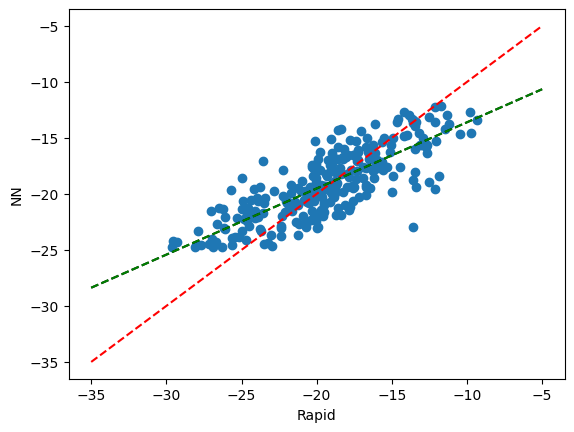

In [54]:
import matplotlib.pyplot as plt
plt.scatter(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values, transport.values)
# plt.scatter(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values, t_merged_argo_2000.sel(time = transport.time, method = 'nearest').values)
plt.xlabel('Rapid')
plt.ylabel('NN')
plt.plot([-35, -5], [-35, -5], 'r--')

from sklearn.linear_model import LinearRegression

lr = LinearRegression().fit(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values.reshape(-1, 1), transport.values.reshape(-1, 1))
in_X = np.linspace(-35, -5, 100).reshape(-1, 1)
plt.plot(in_X, lr.predict(in_X), 'k--')
# lr = LinearRegression().fit(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values.reshape(-1, 1), t_merged_argo_2000.sel(time = transport.time, method = 'nearest').values.reshape(-1, 1))
in_X = np.linspace(-35, -5, 100).reshape(-1, 1)
plt.plot(in_X, lr.predict(in_X), 'g--')

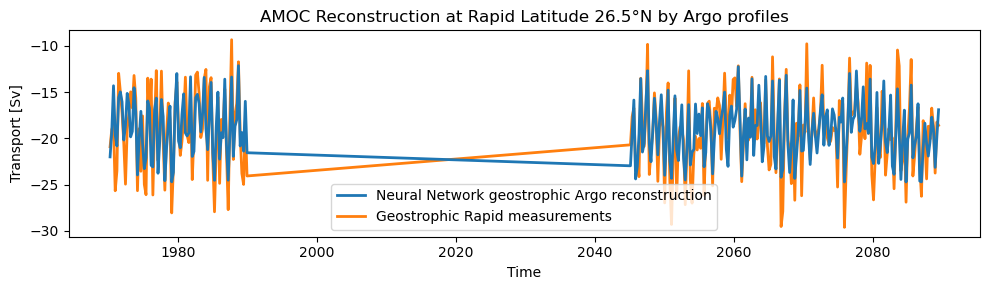

In [55]:
fig = plt.figure(figsize=(10, 3))
ax = fig.add_subplot(1,1,1)

# calc = t_merged_argo_2000.sel(time = transport.time, method = 'nearest')
# ax.plot(calc.time, calc.values, label = 'Geostrohphic calculation from Argos', alpha = .5, color = 'black')
rapid = t_umo_obs.sel(time = transport.time, method = 'nearest')
ax.plot(transport.time, transport.values, label = 'Neural Network geostrophic Argo reconstruction', linewidth = 2, zorder = 20)
ax.plot(rapid.time, rapid.dv_dz_times_X.values, label = 'Geostrophic Rapid measurements', linewidth = 2)

plt.legend()
ax.set_ylabel('Transport [Sv]')
ax.set_xlabel('Time')
plt.title('AMOC Reconstruction at Rapid Latitude 26.5°N by Argo profiles')
fig.tight_layout()
plt.savefig('argo_nn_reconstruction.png')

In [56]:
(
    train_dataset.y.rename('Train').hvplot.kde()
    * val_dataset.y.rename('Validation').hvplot.kde()
    * test_dataset.y.rename('Test').hvplot.kde()
)

:Overlay
   .NdOverlay.I   :NdOverlay   [Variable]
      :Distribution   [value]   (Density)
   .NdOverlay.II  :NdOverlay   [Variable]
      :Distribution   [value]   (Density)
   .NdOverlay.III :NdOverlay   [Variable]
      :Distribution   [value]   (Density)

In [34]:
import matplotlib.pyplot as plt

def test_assignments(epoch_i, na):

        lons = np.linspace(-80, -20, 100)
        lons_scaled = (lons - train_dataset.min_longitude) / (train_dataset.max_longitude - train_dataset.min_longitude)
        days = np.linspace(-45, 45, 100) 
        days_scaled = days / (pd.Timedelta(time_smoothing).days / 2)

        XX, YY = np.meshgrid(lons_scaled, days_scaled)
        labels = na( torch.tensor(np.stack([XX, YY], axis = -1).reshape(-1, 2)).float().to(device)).cpu().detach().numpy().argmax(axis = -1).reshape(XX.shape)

        fig, ax = plt.subplots(1, 1, figsize = (10, 5))

        cf = ax.pcolormesh(lons, days, labels,vmin = -.5, vmax = 19.5, cmap='tab20')

        plt.colorbar(cf, ticks = np.arange(0, 20))

        fig.savefig(f'../rapid-geostrophic-reconstruction/figs/node_assignments_{epoch_i}.png')

        plt.close(fig)

test_assignments(0, model.node_assigner)





#### From top to bottom 
-   20meter R2 0.37%; MAE 2.19; MSE 7.55
-  100meter R2 0.38%; MAE 2.21; MSE 7.47
-  200meter R2 0.46%; MAE 2.00; MSE 6.47
-  400meter R2 0.22%; MAE 2.40; MSE 9.42
-  500meter R2 0.20%; MAE 2.53; MSE 9.68
-  750meter R2 0.38%; MAE 2.15; MSE 7.47
- 1000meter R2 0.37%; MAE 2.15; MSE 7.52
- 1500meter R2 0.28%; MAE 2.38; MSE 8.65
- 2000meter R2 0.54%; MAE 1.77; MSE 5.48


#### From bottom to top
-   20meter R2 0.28%; MAE 2.31; MSE 8.67
-  200meter R2 0.27%; MAE 2.34; MSE 8.82
-  500meter R2 0.20%; MAE 2.49; MSE 9.66
- 1000meter R2 0.21%; MAE 2.48; MSE 9.56
- 1500meter R2 0.18%; MAE 2.57; MSE 9.87


#### Inbetween 
- 0-20 and 1500-2000 R2 0.48%; MAE 1.92; MSE 6.25
- 0-100 and 1500-200 R2 0.55%; MAE 1.86; MSE 5.36


### Transfer this to a RPAID dataset 

In [61]:
torch.save(best_model.cpu().state_dict(), '../rapid-geostrophic-reconstruction/data/11_viking_gesotrophic_prediction_multiple_cycles.pt')

## Compare embeddings 

In [50]:
ds_argo_merged_10days_std = ds_argo_merged_10days_std.sortby('z')
ds_argo_merged_10days_std

<xarray.Dataset>
Dimensions:       (time: 485, pos: 671, z: 29)
Coordinates:
  * time          (time) datetime64[ns] 1970-04-01 1970-06-30 ... 2089-07-05
  * pos           (pos) int64 0 1 2 3 4 5 6 7 ... 664 665 666 667 668 669 670
  * z             (z) float32 -1.85e+03 -1.655e+03 -1.471e+03 ... -9.454 -3.047
    lon           (time, pos) float32 -34.6 -68.3 -62.8 -16.55 ... nan nan nan
    lat           (time, pos) float32 25.88 27.11 28.08 28.72 ... nan nan nan
    time_1d       (time, pos) datetime64[ns] 1970-02-16T12:00:00 ... NaT
    pressure      (z) float32 1.85e+03 1.655e+03 1.471e+03 ... 16.36 9.454 3.047
Data variables:
    temperature   (time, pos, z) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    salinity      (time, pos, z) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    profile_mask  (time, pos, z) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    ct            (time, pos, z) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    rho           (time, pos, z) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

In [51]:
stacked = ds_argo_merged_10days_std.stack(profile = ['time', 'pos'])
stacked = stacked.where(stacked.profile_mask.any('z'), drop = True)

# stacked_train = ds_argo_merged_10days_std.isel(time = train_indices).stack(profile = ['time', 'pos'])
# stacked_train = stacked_train.where(stacked_train.profile_mask.any('z'), drop = True)

# stacked_test = ds_argo_merged_10days_std.isel(time = test_indices).stack(profile = ['time', 'pos'])
# stacked_test = stacked_test.where(stacked_test.profile_mask.any('z'), drop = True)

In [52]:
## Copied code from 06

def load_merged_argo_dataset_and_tumo_argo(time_smoothing, lat_bounds = None):
    ds_argo_merged = xr.open_dataset(f'../rapid-geostrophic-reconstruction/data/ds_argo_{time_smoothing}.nc')
    t_umo_obs = xr.open_dataset(f'../rapid-geostrophic-reconstruction/data/t_umo_obs.nc')

    t_umo_obs = t_umo_obs.resample(time = time_smoothing).mean()

    ds_argo_merged = ds_argo_merged.sel(time = t_umo_obs.time.data)#, method = 'nearest')
    ds_argo_merged = ds_argo_merged.isel(z = slice(None, None, -1))

    if lat_bounds is not None:
        ds_argo_merged = ds_argo_merged.where((ds_argo_merged.lat >= lat_bounds[0]) & (ds_argo_merged.lat <= lat_bounds[1]))

    return ds_argo_merged, t_umo_obs


def create_argo_set():
    ds_argo_merged_10days, t_umo_10days = load_merged_argo_dataset_and_tumo_argo(time_smoothing, lat_bounds = lat_bounds)

    compartments = [
        ['west_p', -76.74, -70, 'west'],
        ['mar_west_p', -60, -47, 'east'],
        ['mar_east_p', -47, -40, 'west'],
        ['east_p', -30, -13.5, 'east']
    ]

    ds_argo_merged_sim = xr.open_dataset(f'../rapid-geostrophic-reconstruction/data/ds_argo_{time_smoothing}_viking.nc')
    depth_boundaries = np.diff(ds_argo_merged_sim.z.values)
    depth_boundaries = (depth_boundaries / 2) + ds_argo_merged_sim.z.values[:-1]

    grouped_depth_profile = ds_argo_merged_10days.groupby_bins('z', np.concatenate([depth_boundaries, [0.0]])).mean()
    ds_argo_merged_10days = grouped_depth_profile.assign_coords(z_bins = ds_argo_merged_sim.z.values[1:]).rename({'z_bins': 'z'}).interpolate_na('z')

    ds_argo_merged_10days = ds_argo_merged_10days.transpose('time', 'z', 'pos')


    # We only take the first 2000 meters depth
    ds_argo_merged_10days = ds_argo_merged_10days.where(ds_argo_merged_10days.z > -2000, drop = True)

    ds_argo_merged_10days = ds_argo_merged_10days.where(ds_argo_merged_10days.salinity > 0)

    return ds_argo_merged_10days

ds_argo_merged_10days_argo = create_argo_set()

rho_mean = ds_argo_merged_10days_argo.where(ds_argo_merged_10days_argo.profile_mask).mean(['time', 'pos']).rho

ds_argo_merged_10days_std_argo = standardize_rho(
    ds_argo_merged_10days_argo,
    rho_mean=rho_mean, 
    rho_std=rho_std,
)

ds_argo_merged_10days_std_argo = ds_argo_merged_10days_std_argo.fillna(0)

# ds_argo_merged_10days_std_argo = standardize_temperature(
#     ds_argo_merged_10days_std_argo,
#     temperature_mean=temperature_mean,
#     temperature_std=temperature_std,
# )

# ds_argo_merged_10days_std_argo = standardize_salinity(
#     ds_argo_merged_10days_std_argo,
#     salinity_mean=salinity_mean,
#     salinity_std=salinity_std,
# )


ds_argo_merged_10days_std_argo = ds_argo_merged_10days_std_argo.sortby('z')
stacked_argo = ds_argo_merged_10days_std_argo.stack(profile = ['time', 'pos'])
stacked_argo = stacked_argo.where(stacked_argo.profile_mask.any('z'), drop = True)


/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


In [53]:
from sklearn.manifold import TSNE




In [98]:
sample_per_batch = 8_000

# select a random sample of profiles 

sample_indices = np.random.choice(np.arange(len(stacked.profile)), sample_per_batch, replace = False)
# sample_indices_train = np.random.choice(np.arange(len(stacked_train.profile)), sample_per_batch, replace = False)
# sample_indices_test = np.random.choice(np.arange(len(stacked_test.profile)), sample_per_batch, replace = False)
sample_indices_argo = np.random.choice(np.arange(len(stacked_argo.profile)), sample_per_batch, replace = False)

variable = 'rho'

X_sample = stacked.isel(profile = sample_indices).drop_vars('profile')[variable].values.T
# X_sample_train = stacked_train.isel(profile = sample_indices_train).drop_vars('profile')[variable].values.T
# X_sample_test = stacked_test.isel(profile = sample_indices_test).drop_vars('profile')[variable].values.T

X_argo = stacked_argo.isel(profile = sample_indices_argo).drop_vars('profile')[variable].values.T


/scratch/SlurmTMP/smomw507.12903553/ipykernel_4150254/3322654542.py:12: DeprecationWarning: Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'pos', 'time'} to avoid an error in the future.
  X_sample = stacked.isel(profile = sample_indices).drop_vars('profile')[variable].values.T
/scratch/SlurmTMP/smomw507.12903553/ipykernel_4150254/3322654542.py:16: DeprecationWarning: Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'pos', 'time'} to avoid an error in the future.
  X_argo = stacked_argo.isel(profile = sample_indices_argo).drop_vars('profile')[variable].values.T


In [99]:
X_sample.shape, X_argo.shape

((8000, 29), (8000, 29))

In [100]:
dataset = np.concatenate([X_sample, X_argo], axis = 0)
labels = np.concatenate(
    [np.ones(X_sample.shape[0]) * 0,
    np.ones(X_argo.shape[0]) * 1]
)


In [101]:
labels.shape

(16000,)

In [71]:
from sklearn.manifold import TSNE
mapped_points = TSNE(n_components=2, perplexity=30, n_iter=3000).fit_transform(dataset)

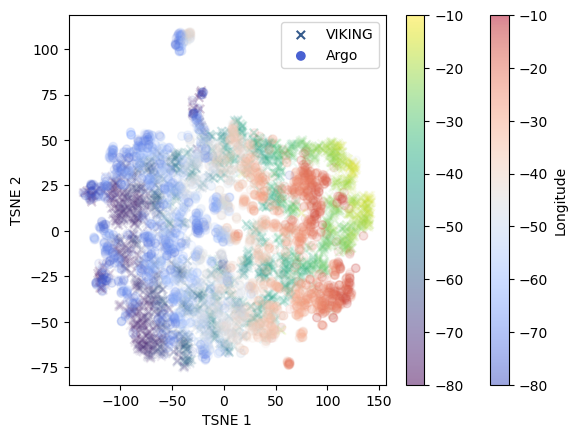

In [72]:
fig = plt.figure()
ax = fig.add_subplot(1,1,1)
alpha = .0825464
v_scatter = ax.scatter(mapped_points[:sample_per_batch, 0], mapped_points[:sample_per_batch,1], alpha = alpha, label = 'VIKING', c = stacked.isel(profile = sample_indices).lon.values, marker = 'x', vmin = -80, vmax = -10)
a_scatter = ax.scatter(mapped_points[sample_per_batch:, 0], mapped_points[sample_per_batch:,1], alpha = alpha, label = 'Argo', c= stacked_argo.isel(profile = sample_indices_argo).lon.values, marker = 'o', vmin = -80, vmax = -10, cmap='coolwarm')

# make a colorbar that is not tranpsarent for the argo scatter plot
cb = plt.colorbar(a_scatter, ax = ax,label = 'Longitude')
cb.solids.set_alpha(.5)

cb = fig.colorbar(v_scatter, ax = ax)
cb.solids.set_alpha(.5)

ax.set_xlabel('TSNE 1')
ax.set_ylabel('TSNE 2')


legend = plt.legend()
for lh in legend.legend_handles:
    lh.set_alpha(1)

In [73]:
fig.savefig('../rapid-geostrophic-reconstruction/argo_viking_tsne_rho.png', dpi = 300)

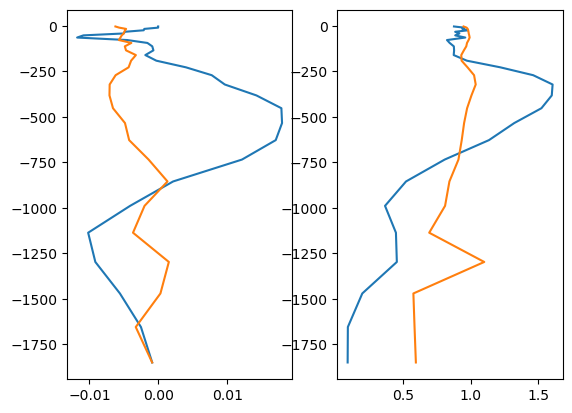

In [102]:
fig = plt.figure()
ax = fig.add_subplot(1,2,1)
ax.plot( X_sample.mean(axis = 0), ds_argo_merged_10days_std.z)
ax.plot( X_argo.mean(axis = 0), ds_argo_merged_10days_std.z)


ax = fig.add_subplot(1,2,2)
ax.plot( X_sample.std(axis = 0), ds_argo_merged_10days_std.z)
ax.plot( X_argo.std(axis = 0), ds_argo_merged_10days_std.z)


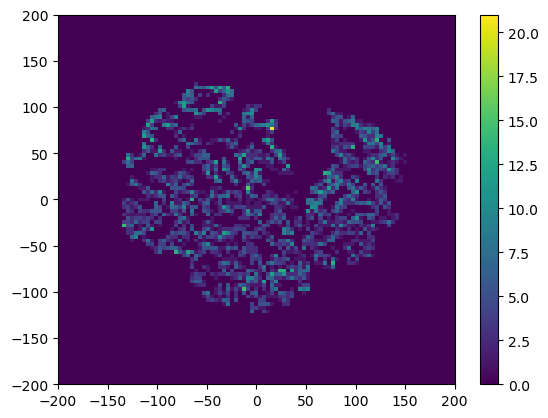

In [149]:
fig = plt.figure()
ax = fig.add_subplot(1,1,1)
bound = 200

a, _, _, h2d = ax.hist2d(mapped_points[5000:, 0], mapped_points[5000:,1], bins = np.linspace(-bound, bound, 100), cmap = 'viridis')
b, _, _, _ = ax.hist2d(mapped_points[:5000, 0], mapped_points[:5000,1], bins = np.linspace(-bound, bound, 100), cmap = 'viridis')
fig.colorbar(h2d, ax = ax)

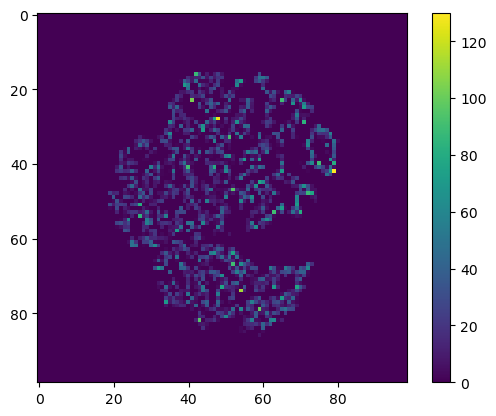

In [150]:
i = plt.imshow(a * b)
plt.colorbar(i)

In [105]:
dataset.shape

(16000, 29)

In [106]:
import torch.utils

data_tensor = torch.Tensor(dataset)
labels_tensor = torch.Tensor(labels).reshape(-1, 1)




In [107]:
data_tensor.shape

torch.Size([16000, 29])

In [108]:
indices = np.arange(len(dataset))
np.random.shuffle(indices)

train_indices = indices[:int(len(dataset) * .8)]
val_indices = indices[int(len(dataset) * .8):int(len(dataset) * .9)]
test_indices = indices[int(len(dataset) * .9):]


train_dataset = torch.utils.data.TensorDataset(data_tensor[train_indices], labels_tensor[train_indices])
val_dataset = torch.utils.data.TensorDataset(data_tensor[val_indices], labels_tensor[val_indices])
test_dataset = torch.utils.data.TensorDataset(data_tensor[test_indices], labels_tensor[test_indices])


train_dl = DataLoader(train_dataset, batch_size = 32, shuffle = True)
val_dl = DataLoader(val_dataset, batch_size = 32, shuffle = False)
test_dl = DataLoader(test_dataset, batch_size = 32, shuffle = False)


In [109]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score

lr = SVC().fit(dataset[train_indices], labels[train_indices])


prediction =lr.predict(dataset[test_indices])


print(confusion_matrix(labels[test_indices], prediction), f1_score(labels[test_indices], prediction), accuracy_score(labels[test_indices], prediction))

[[774  53]
 [ 22 751]] 0.9524413443246671 0.953125


In [18]:
from torch.autograd import Function

class GradReverse(Function):
    @staticmethod
    def forward(ctx, x):
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return (grad_output * -1)

# def grad_reverse(x):
#     return GradReverse.apply(x)


class Profile_Encoder(nn.Module):
    
        def __init__(self, hidden):
            super(Profile_Encoder, self).__init__()
            self.hidden = hidden
            self.fc1 = nn.Linear(29, self.hidden)
            self.fc2 = nn.Linear(self.hidden, self.hidden)
            self.fc3 = nn.Linear(self.hidden, self.hidden)
    
        def forward(self, x):
            x = torch.relu(self.fc1(x))
            x = torch.relu(self.fc2(x))
            x = torch.relu(self.fc3(x))
            return x

class Model(nn.Module):

    def __init__(self, hidden):
        super(Model, self).__init__()
        self.hidden = hidden
        self.fc1 = nn.Linear(29, self.hidden)
        self.fc2 = nn.Linear(self.hidden, self.hidden)

        self.encoder = Profile_Encoder(self.hidden)
        
        self.domain_fc1 = nn.Linear(self.hidden, self.hidden)
        self.domain_fc2 = nn.Linear(self.hidden, self.hidden)
        self.domain_fc3 = nn.Linear(self.hidden, 1)
        self.decoder_fc1 = nn.Linear(self.hidden, self.hidden)
        self.decoder_fc3 = nn.Linear(self.hidden, 29)
        self.grad_reverse = GradReverse.apply

    def forward(self, x):
        x = self.encoder(x)

        domain = self.grad_reverse(x)
        domain = torch.relu(self.domain_fc1(domain))
        domain = torch.relu(self.domain_fc2(domain))
        domain = torch.sigmoid(self.domain_fc3(domain))
        decoder = torch.relu(self.decoder_fc1(x))
        decoder = self.decoder_fc3(decoder)
        return decoder, domain
    

       

In [44]:
 
hidden_dim = 4
model = Model(hidden_dim)

criterion_mse = nn.MSELoss()
criterion_bce = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr = .001)
num_epochs = 100
lr_scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)


def cacl_loss(output_recons, output_domain, target, domain):
    return criterion_mse(output_recons, target) + 10 * criterion_bce(output_domain, domain)

best_val_loss = 1e10
best_epoch = 0
for epoch in range(num_epochs):

    model.train()
    for i, (data, domain) in enumerate(train_dl):
        optimizer.zero_grad()
        output = model(data)
        loss = cacl_loss(*output, data, domain)
        loss.backward()
        optimizer.step()

    model.eval()
    total_val_loss = 0.
    for i, (data, domain) in enumerate(val_dl):
        output = model(data)
        loss = cacl_loss(*output, data, domain)
        total_val_loss += loss.item()
    total_val_loss /= len(val_dl)

    if total_val_loss < best_val_loss:
        best_val_loss = total_val_loss
        best_epoch = epoch
        best_model = deepcopy(model)
        print('New best model found in epoch: ', epoch, 'with val loss: ', total_val_loss)


    lr_scheduler.step()
    print(f'Epoch {epoch}, Loss: {loss.item()}, Val loss: {total_val_loss}')

    if epoch - best_epoch > 20: 
        break

model = best_model

NameError: name 'train_dl' is not defined

In [259]:
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix

In [260]:
gt_domain = []
pred_domain = []

gt_recons = []
pred_recons = []

for i, (data, domain) in enumerate(test_dl):
    output = model(data)
    loss = cacl_loss(*output, data, domain)

    # calculate the F1 score
    gt_domain.append(domain.detach().numpy())
    pred_domain.append(output[1].detach().numpy())

    gt_recons.append(data.detach().numpy())
    pred_recons.append(output[0].detach().numpy())




gt_domain = np.concatenate(gt_domain)
pred_domain = np.concatenate(pred_domain)

gt_recons = np.concatenate(gt_recons)
pred_recons = np.concatenate(pred_recons)

gt_domain = gt_domain >.5
pred_domain = pred_domain > .5

print(f'F1 score: {f1_score(gt_domain, pred_domain):.4f}; Accuracy: {accuracy_score(gt_domain, pred_domain)*100:.2f}%', confusion_matrix(gt_domain, pred_domain))

F1 score: 0.6515; Accuracy: 48.31% [[  0 827]
 [  0 773]]


In [261]:
(np.concatenate([gt_domain, pred_domain], axis = -1).sum(axis = -1) == 0).sum()

0

In [262]:
((gt_recons - pred_recons)**2).mean(axis = 0),((gt_recons - pred_recons)**2).mean() 

(array([0.00153284, 0.00208379, 0.00517814, 0.00456012, 0.00210057,
        0.00532934, 0.02333547, 0.01432924, 0.01153489, 0.01217476,
        0.00955706, 0.00920643, 0.00913786, 0.00883615, 0.00948532,
        0.00868371, 0.01073394, 0.01099734, 0.00938999, 0.01002004,
        0.01869649, 0.00915271, 0.00758209, 0.01186616, 0.00753374,
        0.00411739, 0.00433291, 0.00454387, 0.00991071], dtype=float32),
 0.008825625)

In [263]:
assert ((gt_recons - pred_recons)**2).mean() < .1

In [264]:
embedded_profiles = model.encoder(data_tensor).detach().numpy()
embedded_profiles.shape

(16000, 24)

In [265]:
from sklearn.manifold import TSNE
mapped_points = TSNE(n_components=2, perplexity=30, n_iter=3000).fit_transform(embedded_profiles)

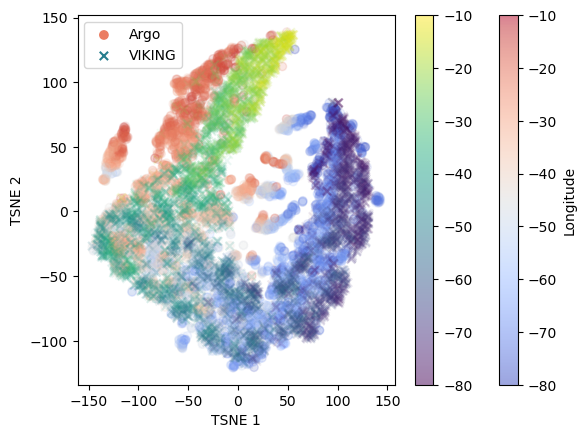

In [266]:
fig = plt.figure()
ax = fig.add_subplot(1,1,1)
alpha = .0825464
a_scatter = ax.scatter(mapped_points[sample_per_batch:, 0], mapped_points[sample_per_batch:,1], alpha = alpha, label = 'Argo', c= stacked_argo.isel(profile = sample_indices_argo).lon.values, marker = 'o', vmin = -80, vmax = -10, cmap='coolwarm')
v_scatter = ax.scatter(mapped_points[:sample_per_batch, 0], mapped_points[:sample_per_batch,1], alpha = alpha, label = 'VIKING', c = stacked.isel(profile = sample_indices).lon.values, marker = 'x', vmin = -80, vmax = -10)

# make a colorbar that is not tranpsarent for the argo scatter plot
cb = plt.colorbar(a_scatter, ax = ax,label = 'Longitude')
cb.solids.set_alpha(.5)

cb = fig.colorbar(v_scatter, ax = ax)
cb.solids.set_alpha(.5)

ax.set_xlabel('TSNE 1')
ax.set_ylabel('TSNE 2')


legend = plt.legend()
for lh in legend.legend_handles:
    lh.set_alpha(1)

In [267]:
from sklearn.svm import SVC

lr = SVC().fit(embedded_profiles[train_indices], labels[train_indices])

prediction =lr.predict(embedded_profiles[test_indices])


test_labels = labels[test_indices]
print(confusion_matrix(test_labels, prediction), f1_score(test_labels, prediction), accuracy_score(test_labels, prediction))

assert f1_score(test_labels, prediction) < .64

[[639 188]
 [104 669]] 0.8208588957055215 0.8175


AssertionError: 

In [ ]:
[b.shape for b in model.encoder.state_dict().values()]

[torch.Size([8, 29]),
 torch.Size([8]),
 torch.Size([8, 8]),
 torch.Size([8]),
 torch.Size([8, 8]),
 torch.Size([8])]

In [ ]:
torch.save(model.encoder.state_dict(), f'../rapid-geostrophic-reconstruction/profile_encoder_{hidden_dim}dim.pt')